In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [181]:
fire_df = pd.read_csv("../data/raw/data.csv")

fire_df.head()

,Date,District,fireCount
0,2016-04-01,Amritsar,0.0
1,2016-04-01,Barnala,0.0
2,2016-04-01,Bathinda,0.0
3,2016-04-01,Faridkot,0.0
4,2016-04-01,Fatehgarh Sahib,0.0


In [182]:
fire_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66074 entries, 0 to 66073
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       66074 non-null  str    
 1   District   66074 non-null  str    
 2   fireCount  66074 non-null  float64
dtypes: float64(1), str(2)
memory usage: 1.5 MB


In [183]:
print("Shape:", fire_df.shape)

print("\nNumber of districts:", fire_df["District"].nunique())

print("\nDistricts:")
print(sorted(fire_df["District"].unique()))

Shape: (66074, 3)

Number of districts: 23

Districts:
['Amritsar', 'Barnala', 'Bathinda', 'Faridkot', 'Fatehgarh Sahib', 'Fazilka', 'Firozpur', 'Gurdaspur', 'Hoshiarpur', 'Jalandhar', 'Kapurthala', 'Ludhiana', 'Malerkotla', 'Mansa', 'Moga', 'Muktsar', 'Pathankot', 'Patiala', 'Rupnagar', 'SAS Nagar', 'SBS Nagar', 'Sangrur', 'Tarn Taran']


In [184]:
print("Start date:", fire_df["Date"].min())
print("End date:", fire_df["Date"].max())

Start date: 2016-04-01
End date: 2024-06-05


In [185]:
duplicates = fire_df[fire_df.duplicated(
    subset=["Date", "District"],
    keep=False
)]

print("Rows involved in duplicate Date-District combinations:", len(duplicates))
print("Number of duplicate Date-District combinations:",
      duplicates[["Date", "District"]].drop_duplicates().shape[0])

duplicates.sort_values(["Date", "District"]).head(20)

Rows involved in duplicate Date-District combinations: 470
Number of duplicate Date-District combinations: 234


,Date,District,fireCount
44386,2021-10-09,Malerkotla,1.0
44387,2021-10-09,Malerkotla,0.0
44454,2021-10-12,Malerkotla,1.0
44455,2021-10-12,Malerkotla,0.0
44500,2021-10-14,Malerkotla,2.0
44501,2021-10-14,Malerkotla,0.0
44524,2021-10-15,Malerkotla,3.0
44525,2021-10-15,Malerkotla,0.0
44548,2021-10-16,Malerkotla,2.0
44549,2021-10-16,Malerkotla,0.0


In [186]:
malerkotla = fire_df[fire_df["District"] == "Malerkotla"].copy()

print("Total Malerkotla rows:", len(malerkotla))
print("Start date:", malerkotla["Date"].min())
print("End date:", malerkotla["Date"].max())

print("\nFirst 20 rows:")
print(malerkotla.head(20))

print("\nRows with fireCount > 0:")
print((malerkotla["fireCount"] > 0).sum())

print("\nRows with fireCount == 0:")
print((malerkotla["fireCount"] == 0).sum())

Total Malerkotla rows: 338
Start date: 2021-10-09
End date: 2024-05-31

First 20 rows:
             Date    District  fireCount
44386  2021-10-09  Malerkotla        1.0
44387  2021-10-09  Malerkotla        0.0
44454  2021-10-12  Malerkotla        1.0
44455  2021-10-12  Malerkotla        0.0
44500  2021-10-14  Malerkotla        2.0
44501  2021-10-14  Malerkotla        0.0
44524  2021-10-15  Malerkotla        3.0
44525  2021-10-15  Malerkotla        0.0
44548  2021-10-16  Malerkotla        2.0
44549  2021-10-16  Malerkotla        0.0
44616  2021-10-19  Malerkotla        1.0
44617  2021-10-19  Malerkotla        0.0
44640  2021-10-20  Malerkotla        2.0
44641  2021-10-20  Malerkotla        0.0
44664  2021-10-21  Malerkotla        2.0
44665  2021-10-21  Malerkotla        0.0
44688  2021-10-22  Malerkotla        2.0
44689  2021-10-22  Malerkotla        0.0
44712  2021-10-23  Malerkotla       10.0
44713  2021-10-23  Malerkotla        0.0

Rows with fireCount > 0:
169

Rows with fireCount =

In [187]:
duplicate_groups = (
    fire_df
    .groupby(["Date", "District"])["fireCount"]
    .agg(["count", "sum", "max"])
    .reset_index()
)

duplicate_groups = duplicate_groups[duplicate_groups["count"] > 1]

print("Duplicate groups:", len(duplicate_groups))

print("\nDuplicate groups with MORE THAN ONE non-zero value:")
print(
    fire_df[fire_df["fireCount"] > 0]
    .groupby(["Date", "District"])
    .size()
    .loc[lambda x: x > 1]
)

Duplicate groups: 234

Duplicate groups with MORE THAN ONE non-zero value:
Date        District  
2024-04-30  Barnala       2
            Bathinda      2
            Mansa         2
            SAS Nagar     2
            Sangrur       2
2024-05-31  Bathinda      2
            Gurdaspur     2
            Hoshiarpur    2
            Kapurthala    2
            Malerkotla    2
            Patiala       2
dtype: int64


In [188]:
multi_nonzero = (
    fire_df[fire_df["fireCount"] > 0]
    .groupby(["Date", "District"])
    .size()
)

multi_nonzero = multi_nonzero[multi_nonzero > 1]

problem_rows = fire_df.merge(
    multi_nonzero.reset_index()[["Date", "District"]],
    on=["Date", "District"],
    how="inner"
)

problem_rows.sort_values(["Date", "District"])

,Date,District,fireCount
0,2024-04-30,Barnala,1.0
5,2024-04-30,Barnala,1.0
1,2024-04-30,Bathinda,1.0
6,2024-04-30,Bathinda,5.0
2,2024-04-30,Mansa,2.0
7,2024-04-30,Mansa,3.0
3,2024-04-30,SAS Nagar,2.0
8,2024-04-30,SAS Nagar,1.0
4,2024-04-30,Sangrur,2.0
9,2024-04-30,Sangrur,5.0


In [189]:
duplicate_comparison = (
    fire_df
    .groupby(["Date", "District"])["fireCount"]
    .agg(["count", "sum", "max"])
    .reset_index()
)

duplicate_comparison = duplicate_comparison[
    duplicate_comparison["count"] > 1
]

duplicate_comparison["difference"] = (
    duplicate_comparison["sum"] -
    duplicate_comparison["max"]
)

print("Duplicate groups:", len(duplicate_comparison))

print(
    "\nGroups where SUM and MAX differ:",
    (duplicate_comparison["difference"] > 0).sum()
)

print(
    "\nTotal extra fire count introduced by SUM:",
    duplicate_comparison["difference"].sum()
)

duplicate_comparison.sort_values(
    "difference", ascending=False
).head(15)

Duplicate groups: 234

Groups where SUM and MAX differ: 11

Total extra fire count introduced by SUM: 14.0


,Date,District,count,sum,max,difference
65713,2024-05-31,Hoshiarpur,2,4.0,2.0,2.0
65044,2024-04-30,Sangrur,2,7.0,5.0,2.0
65036,2024-04-30,Mansa,2,5.0,3.0,2.0
65715,2024-05-31,Kapurthala,2,3.0,2.0,1.0
65707,2024-05-31,Bathinda,2,9.0,8.0,1.0
65042,2024-04-30,SAS Nagar,2,3.0,2.0,1.0
65025,2024-04-30,Barnala,2,2.0,1.0,1.0
65712,2024-05-31,Gurdaspur,2,3.0,2.0,1.0
65722,2024-05-31,Patiala,2,3.0,2.0,1.0
65026,2024-04-30,Bathinda,2,6.0,5.0,1.0


In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fire_df = pd.read_csv("../data/raw/data.csv")
print(fire_df.shape)

(66074, 3)


In [191]:
fire_clean = fire_df.copy()

In [192]:
fire_clean["Date"] = pd.to_datetime(fire_clean["Date"])

In [193]:
fire_clean = (
    fire_clean
    .groupby(["Date", "District"], as_index=False)["fireCount"]
    .max()
)

In [194]:
print("Original rows:", len(fire_df))
print("Cleaned rows:", len(fire_clean))

print("\nDuplicate Date-District combinations after cleaning:",
      fire_clean.duplicated(["Date", "District"]).sum())

print("\nData types:")
print(fire_clean.dtypes)

Original rows: 66074
Cleaned rows: 65838

Duplicate Date-District combinations after cleaning: 0

Data types:
Date         datetime64[us]
District                str
fireCount           float64
dtype: object


In [195]:
fire_clean.to_csv(
    "../data/processed/cleaned_fire.csv",
    index=False
)

In [196]:
import os

print(os.path.exists("../data/processed/cleaned_fire.csv"))

True


In [197]:
fire_clean.head()

,Date,District,fireCount
0,2016-04-01,Amritsar,0.0
1,2016-04-01,Barnala,0.0
2,2016-04-01,Bathinda,0.0
3,2016-04-01,Faridkot,0.0
4,2016-04-01,Fatehgarh Sahib,0.0


In [198]:
fire_clean.tail()

,Date,District,fireCount
65833,2024-06-05,Rupnagar,0.0
65834,2024-06-05,SAS Nagar,0.0
65835,2024-06-05,SBS Nagar,0.0
65836,2024-06-05,Sangrur,0.0
65837,2024-06-05,Tarn Taran,0.0


In [199]:
print("Fire Count Statistics:")
print(fire_clean["fireCount"].describe())

print("\nZero-fire rows:")
print((fire_clean["fireCount"] == 0).sum())

print("\nNon-zero fire rows:")
print((fire_clean["fireCount"] > 0).sum())

print("\nPercentage of zero-fire rows:")
print(
    round(
        (fire_clean["fireCount"] == 0).mean() * 100,
        2
    ),
    "%"
)

Fire Count Statistics:
count    65838.000000
mean         8.744965
std         42.175184
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1007.000000
Name: fireCount, dtype: float64

Zero-fire rows:
53298

Non-zero fire rows:
12540

Percentage of zero-fire rows:
80.95 %


In [200]:
district_fire = (
    fire_clean
    .groupby("District")["fireCount"]
    .sum()
    .sort_values(ascending=False)
)

district_fire

District
Sangrur            65401.0
Firozpur           49681.0
Bathinda           48741.0
Moga               42735.0
Muktsar            38595.0
Ludhiana           38353.0
Patiala            36847.0
Tarn Taran         33913.0
Mansa              31546.0
Barnala            30778.0
Faridkot           27232.0
Amritsar           22758.0
Fazilka            22748.0
Jalandhar          20303.0
Gurdaspur          18600.0
Kapurthala         16014.0
Fatehgarh Sahib    11348.0
Hoshiarpur          6327.0
SBS Nagar           5004.0
Malerkotla          3019.0
Rupnagar            2503.0
SAS Nagar           1951.0
Pathankot           1354.0
Name: fireCount, dtype: float64

In [201]:
fire_clean["month"] = fire_clean["Date"].dt.month

monthly_fire = (
    fire_clean
    .groupby("month")["fireCount"]
    .sum()
)

monthly_fire

month
1          0.0
2          0.0
3          0.0
4       8970.0
5     100076.0
6          0.0
7          0.0
8          0.0
9       1693.0
10    164286.0
11    300726.0
12         0.0
Name: fireCount, dtype: float64

In [202]:
monthly_fire_avg = (
    fire_clean
    .groupby("month")["fireCount"]
    .mean()
)

monthly_fire_avg

month
1      0.000000
2      0.000000
3      0.000000
4      1.513158
5     16.219773
6      0.000000
7      0.000000
8      0.000000
9      0.320644
10    29.891921
11    56.273578
12     0.000000
Name: fireCount, dtype: float64

In [203]:
monthly_percentage = (
    monthly_fire / monthly_fire.sum() * 100
).round(2)

monthly_percentage

month
1      0.00
2      0.00
3      0.00
4      1.56
5     17.38
6      0.00
7      0.00
8      0.00
9      0.29
10    28.53
11    52.23
12     0.00
Name: fireCount, dtype: float64

In [204]:
print(
    "October + November contribution:",
    round(
        monthly_percentage.loc[[10, 11]].sum(),
        2
    ),
    "%"
)

October + November contribution: 80.76 %


In [205]:
fire_clean["year"] = fire_clean["Date"].dt.year

yearly_fire = (
    fire_clean
    .groupby("year")["fireCount"]
    .sum()
)

yearly_fire

year
2016    91774.0
2017    59820.0
2018    61497.0
2019    66911.0
2020    90010.0
2021    81404.0
2022    64433.0
2023    48016.0
2024    11886.0
Name: fireCount, dtype: float64

In [206]:
district_coverage = (
    fire_clean
    .groupby("District")["Date"]
    .agg(["min", "max", "count"])
    .sort_values("count")
)

district_coverage

,min,max,count
District,,,
Malerkotla,2021-10-09,2024-05-31,168
Amritsar,2016-04-01,2024-06-05,2985
Bathinda,2016-04-01,2024-06-05,2985
Barnala,2016-04-01,2024-06-05,2985
Fatehgarh Sahib,2016-04-01,2024-06-05,2985
Fazilka,2016-04-01,2024-06-05,2985
Firozpur,2016-04-01,2024-06-05,2985
Faridkot,2016-04-01,2024-06-05,2985
Gurdaspur,2016-04-01,2024-06-05,2985


# 02 - AQI Dataset Exploration

In [207]:
aqi_df = pd.read_csv("../data/raw/city_day.csv")

aqi_df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [208]:
aqi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [209]:
print("Shape:", aqi_df.shape)

print("\nNumber of cities:", aqi_df["City"].nunique())

print("\nCities:")
print(sorted(aqi_df["City"].unique()))

Shape: (29531, 16)

Number of cities: 26

Cities:
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


In [210]:
print("Start date:", aqi_df["Date"].min())
print("End date:", aqi_df["Date"].max())

Start date: 2015-01-01
End date: 2020-07-01


In [211]:
missing = aqi_df.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

Xylene        18109
PM10          11140
NH3           10328
Toluene        8041
Benzene        5623
AQI            4681
AQI_Bucket     4681
PM2.5          4598
NOx            4185
O3             4022
SO2            3854
NO2            3585
NO             3582
CO             2059
dtype: int64


In [212]:
print(sorted(aqi_df["City"].unique()))

['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


In [213]:
city_aqi = (
    aqi_df
    .groupby("City")["AQI"]
    .agg(
        total_rows="size",
        aqi_available="count"
    )
)

city_aqi["aqi_missing"] = (
    city_aqi["total_rows"] -
    city_aqi["aqi_available"]
)

city_aqi["aqi_available_pct"] = (
    city_aqi["aqi_available"] /
    city_aqi["total_rows"] * 100
).round(2)

city_aqi.sort_values("aqi_available_pct")

,total_rows,aqi_available,aqi_missing,aqi_available_pct
City,,,,
Mumbai,2009,775,1234,38.58
Jorapokhar,1169,771,398,65.95
Shillong,310,205,105,66.13
Ahmedabad,2009,1334,675,66.40
Talcher,925,698,227,75.46
Brajrajnagar,938,713,225,76.01
Patna,1858,1459,399,78.53
Visakhapatnam,1462,1171,291,80.10
Gurugram,1679,1453,226,86.54


In [214]:
print(aqi_df["AQI"].describe())

count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64


In [215]:
print(
    "Duplicate City-Date rows:",
    aqi_df.duplicated(["City", "Date"]).sum()
)

Duplicate City-Date rows: 0


# 03 - AQI Station Dataset Exploration

In [216]:
station_aqi_df = pd.read_csv("../data/raw/aqi.csv")

station_aqi_df.head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


In [217]:
station_aqi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           235785 non-null  str    
 1   state                          235785 non-null  str    
 2   area                           235785 non-null  str    
 3   number_of_monitoring_stations  235785 non-null  int64  
 4   prominent_pollutants           235785 non-null  str    
 5   aqi_value                      235785 non-null  int64  
 6   air_quality_status             235785 non-null  str    
 7   unit                           235785 non-null  str    
 8   note                           0 non-null       float64
dtypes: float64(1), int64(2), str(6)
memory usage: 16.2 MB


In [218]:
print("Shape:", station_aqi_df.shape)
print("\nColumns:")
print(station_aqi_df.columns.tolist())

Shape: (235785, 9)

Columns:
['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit', 'note']


In [219]:
station_aqi_df.isnull().sum().sort_values(ascending=False)

note                             235785
date                                  0
state                                 0
number_of_monitoring_stations         0
area                                  0
prominent_pollutants                  0
aqi_value                             0
air_quality_status                    0
unit                                  0
dtype: int64

In [220]:
print(station_aqi_df.head(20))

          date           state          area  number_of_monitoring_stations  \
0   30-04-2025     Maharashtra      Amravati                              2   
1   30-04-2025           Bihar        Purnia                              1   
2   30-04-2025  Madhya Pradesh         Katni                              1   
3   30-04-2025    Chhattisgarh       Tumidih                              1   
4   30-04-2025           Assam      Byrnihat                              1   
5   30-04-2025         Manipur        Imphal                              1   
6   30-04-2025          Kerala        Kollam                              1   
7   30-04-2025     West Bengal   Barrackpore                              1   
8   30-04-2025          Odisha      Nayagarh                              1   
9   30-04-2025           Assam       Nalbari                              1   
10  30-04-2025       Karnataka      Hubballi                              1   
11  30-04-2025         Gujarat     Ahmedabad        

In [221]:
print(station_aqi_df.columns.tolist())

['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit', 'note']


In [222]:
station_aqi_df.head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


In [223]:
station_aqi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           235785 non-null  str    
 1   state                          235785 non-null  str    
 2   area                           235785 non-null  str    
 3   number_of_monitoring_stations  235785 non-null  int64  
 4   prominent_pollutants           235785 non-null  str    
 5   aqi_value                      235785 non-null  int64  
 6   air_quality_status             235785 non-null  str    
 7   unit                           235785 non-null  str    
 8   note                           0 non-null       float64
dtypes: float64(1), int64(2), str(6)
memory usage: 16.2 MB


In [224]:
print("Shape:", station_aqi_df.shape)

Shape: (235785, 9)


In [225]:
station_aqi_df["date"] = pd.to_datetime(
    station_aqi_df["date"],
    dayfirst=True
)

print("Start date:", station_aqi_df["date"].min())
print("End date:", station_aqi_df["date"].max())

Start date: 2022-04-01 00:00:00
End date: 2025-04-30 00:00:00


In [226]:
print(
    station_aqi_df[
        station_aqi_df["state"].str.contains(
            "Punjab",
            case=False,
            na=False
        )
    ]["area"].unique()
)

<StringArray>
[       'Jalandhar',          'Patiala',         'Ludhiana',
         'Bathinda',           'Khanna', 'Mandi Gobindgarh',
         'Amritsar',         'Rupnagar']
Length: 8, dtype: str


In [227]:
print("Number of states:", station_aqi_df["state"].nunique())

print("\nStates:")
print(sorted(station_aqi_df["state"].dropna().unique()))

Number of states: 32

States:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [228]:
punjab_aqi = station_aqi_df[
    station_aqi_df["state"] == "Punjab"
].copy()

print("Punjab AQI rows:", len(punjab_aqi))

print("\nAreas:")
print(sorted(punjab_aqi["area"].unique()))

Punjab AQI rows: 8488

Areas:
['Amritsar', 'Bathinda', 'Jalandhar', 'Khanna', 'Ludhiana', 'Mandi Gobindgarh', 'Patiala', 'Rupnagar']


In [229]:
print("\nAQI statistics:")
print(punjab_aqi["aqi_value"].describe())


AQI statistics:
count    8488.000000
mean      117.854265
std        59.304512
min        14.000000
25%        75.000000
50%       104.000000
75%       146.000000
max       417.000000
Name: aqi_value, dtype: float64


In [230]:
punjab_coverage = (
    punjab_aqi
    .groupby("area")["date"]
    .agg(["min", "max", "count"])
    .sort_values("count", ascending=False)
)

punjab_coverage

,min,max,count
area,,,
Ludhiana,2022-04-01,2025-04-30,1112
Patiala,2022-04-01,2025-04-30,1110
Jalandhar,2022-04-01,2025-04-30,1107
Khanna,2022-04-01,2025-04-30,1100
Amritsar,2022-04-01,2025-04-24,1041
Mandi Gobindgarh,2022-04-01,2025-04-27,1010
Bathinda,2022-04-01,2025-04-30,1009
Rupnagar,2022-04-01,2025-04-21,999


In [231]:
print(
    "Duplicate Area-Date rows:",
    punjab_aqi.duplicated(["date", "area"]).sum()
)

Duplicate Area-Date rows: 0


In [232]:
aqi_clean = punjab_aqi.copy()

In [233]:
aqi_clean[
    [
        "date",
        "state",
        "area",
        "number_of_monitoring_stations",
        "prominent_pollutants",
        "aqi_value",
        "air_quality_status"
    ]
].head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status
46,2025-04-30,Punjab,Jalandhar,1,PM2.5,138,Moderate
49,2025-04-30,Punjab,Patiala,1,PM10,118,Moderate
109,2025-04-30,Punjab,Ludhiana,1,PM10,72,Satisfactory
123,2025-04-30,Punjab,Bathinda,1,PM10,154,Moderate
154,2025-04-30,Punjab,Khanna,1,PM10,120,Moderate


In [234]:
aqi_clean.isnull().sum()

date                                0
state                               0
area                                0
number_of_monitoring_stations       0
prominent_pollutants                0
aqi_value                           0
air_quality_status                  0
unit                                0
note                             8488
dtype: int64

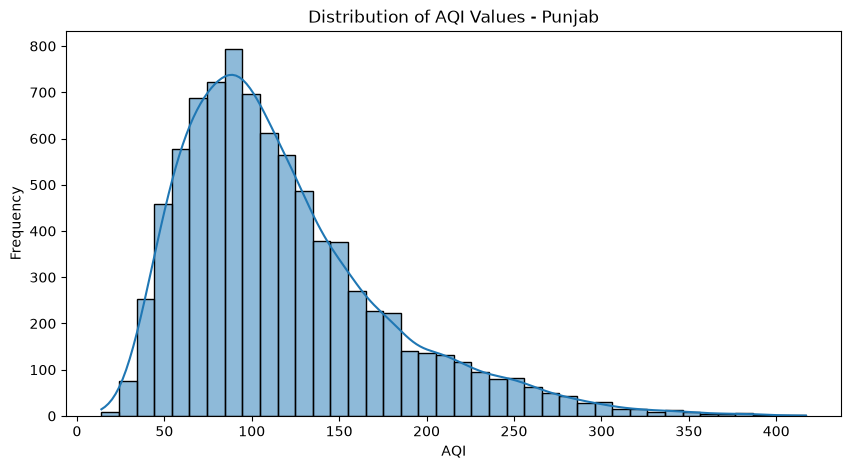

In [235]:
plt.figure(figsize=(10, 5))

sns.histplot(
    aqi_clean["aqi_value"],
    bins=40,
    kde=True
)

plt.title("Distribution of AQI Values - Punjab")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

In [236]:
print(aqi_clean["air_quality_status"].value_counts())

air_quality_status
Moderate        3649
Satisfactory    3384
Poor             777
Good             583
Very Poor         93
Severe             2
Name: count, dtype: int64


In [237]:
aqi_clean["date"].dtype

dtype('<M8[us]')

In [238]:
aqi_clean.to_csv(
    "../data/processed/cleaned_punjab_aqi.csv",
    index=False
)

In [239]:
import os

print(
    os.path.exists(
        "../data/processed/cleaned_punjab_aqi.csv"
    )
)

True


In [240]:
target_areas = [
    "Amritsar",
    "Bathinda",
    "Jalandhar",
    "Ludhiana",
    "Patiala",
    "Rupnagar"
]

aqi_model = aqi_clean[
    aqi_clean["area"].isin(target_areas)
].copy()

print("Rows:", len(aqi_model))
print("\nAreas:")
print(aqi_model["area"].value_counts())

Rows: 6378

Areas:
area
Ludhiana     1112
Patiala      1110
Jalandhar    1107
Amritsar     1041
Bathinda     1009
Rupnagar      999
Name: count, dtype: int64


In [241]:
aqi_model = aqi_model[
    (aqi_model["date"] >= "2022-04-01") &
    (aqi_model["date"] <= "2024-06-05")
].copy()

print("Rows after date filtering:", len(aqi_model))

print(
    "\nDate range:",
    aqi_model["date"].min(),
    "→",
    aqi_model["date"].max()
)

Rows after date filtering: 4518

Date range: 2022-04-01 00:00:00 → 2024-06-05 00:00:00


In [242]:
fire_model = fire_clean[
    (fire_clean["District"].isin(target_areas)) &
    (fire_clean["Date"] >= "2022-04-01") &
    (fire_clean["Date"] <= "2024-06-05")
].copy()

print("Fire rows:", len(fire_model))

print("\nDistricts:")
print(fire_model["District"].value_counts())

Fire rows: 4764

Districts:
District
Amritsar     794
Bathinda     794
Jalandhar    794
Ludhiana     794
Patiala      794
Rupnagar     794
Name: count, dtype: int64


In [243]:
fire_model = fire_model.rename(
    columns={"District": "area"}
)

In [244]:
fire_model = fire_model.rename(
    columns={"Date": "date"}
)

In [245]:
print(fire_model[["date", "area", "fireCount"]].head())

            date       area  fireCount
48237 2022-04-01   Amritsar        0.0
48239 2022-04-01   Bathinda        0.0
48246 2022-04-01  Jalandhar        0.0
48248 2022-04-01   Ludhiana        0.0
48253 2022-04-01    Patiala        0.0


In [246]:
print("AQI rows:", len(aqi_model))

AQI rows: 4518


In [247]:
print("Fire rows:", len(fire_model))

Fire rows: 4764


In [248]:
print(
    "Unique Fire Date-Area combinations:",
    fire_model[["date", "area"]].drop_duplicates().shape[0]
)

print(
    "Unique AQI Date-Area combinations:",
    aqi_model[["date", "area"]].drop_duplicates().shape[0]
)

Unique Fire Date-Area combinations: 4764
Unique AQI Date-Area combinations: 4518


In [249]:
merged_check = pd.merge(
    aqi_model,
    fire_model[["date", "area", "fireCount"]],
    on=["date", "area"],
    how="outer",
    indicator=True
)

print(merged_check["_merge"].value_counts())

_merge
both          4500
right_only     264
left_only       18
Name: count, dtype: int64


In [250]:
model_base = merged_check[
    merged_check["_merge"] == "both"
].drop(columns=["_merge"])

In [251]:
print("Final matched rows:", len(model_base))

print("\nAreas:")
print(model_base["area"].value_counts())

print("\nDate range:")
print(model_base["date"].min(), "→", model_base["date"].max())

Final matched rows: 4500

Areas:
area
Ludhiana     785
Patiala      784
Jalandhar    780
Amritsar     730
Rupnagar     716
Bathinda     705
Name: count, dtype: int64

Date range:
2022-04-01 00:00:00 → 2024-06-05 00:00:00


In [252]:
model_base.to_csv(
    "../data/processed/model_base.csv",
    index=False
)

In [253]:
print(
    os.path.exists(
        "../data/processed/model_base.csv"
    )
)

True


# 04 - Weather Data Integration

In [254]:
import requests
import pandas as pd

In [255]:
locations = {
    "Amritsar": (31.6340, 74.8723),
    "Bathinda": (30.2110, 74.9455),
    "Jalandhar": (31.3260, 75.5762),
    "Ludhiana": (30.9010, 75.8573),
    "Patiala": (30.3398, 76.3869),
    "Rupnagar": (30.9660, 76.5330)
}

In [256]:
latitude, longitude = locations["Amritsar"]

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2022-04-01",
    "end_date": "2022-04-07",
    "daily": ",".join([
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "wind_speed_10m_max",
        "surface_pressure_mean"
    ]),
    "timezone": "Asia/Kolkata",
    "temperature_unit": "celsius",
    "wind_speed_unit": "kmh",
    "precipitation_unit": "mm"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [257]:
weather_test = response.json()

print(weather_test.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])


In [258]:
weather_test_df = pd.DataFrame(
    weather_test["daily"]
)

weather_test_df

,time,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean
0,2022-04-01,25.2,33.2,17.5,40,0.0,11.5,980.0
1,2022-04-02,24.5,33.7,16.2,51,0.0,13.0,980.5
2,2022-04-03,24.7,33.5,18.3,51,0.0,12.8,980.7
3,2022-04-04,25.8,35.1,16.9,44,0.0,10.4,980.9
4,2022-04-05,27.9,35.3,18.9,36,0.0,8.6,983.6
5,2022-04-06,27.5,36.0,17.6,38,0.0,10.8,983.3
6,2022-04-07,27.8,37.4,19.4,36,0.0,13.0,982.4


In [259]:
def get_weather_data(city, latitude, longitude, start_date, end_date):

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": ",".join([
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "relative_humidity_2m_mean",
            "precipitation_sum",
            "wind_speed_10m_max",
            "surface_pressure_mean"
        ]),
        "timezone": "Asia/Kolkata",
        "temperature_unit": "celsius",
        "wind_speed_unit": "kmh",
        "precipitation_unit": "mm"
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        print(f"Failed for {city}: {response.status_code}")
        return None

    data = response.json()

    weather_df = pd.DataFrame(data["daily"])

    weather_df["area"] = city

    return weather_df

In [260]:
amritsar_weather = get_weather_data(
    "Amritsar",
    *locations["Amritsar"],
    "2022-04-01",
    "2024-06-05"
)

amritsar_weather.head()

,time,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean,area
0,2022-04-01,25.2,33.2,17.5,40,0.0,11.5,980.0,Amritsar
1,2022-04-02,24.5,33.7,16.2,51,0.0,13.0,980.5,Amritsar
2,2022-04-03,24.7,33.5,18.3,51,0.0,12.8,980.7,Amritsar
3,2022-04-04,25.8,35.1,16.9,44,0.0,10.4,980.9,Amritsar
4,2022-04-05,27.9,35.3,18.9,36,0.0,8.6,983.6,Amritsar


In [261]:
print(amritsar_weather.shape)
print(amritsar_weather.tail())

(797, 9)
           time  temperature_2m_mean  temperature_2m_max  temperature_2m_min  \
792  2024-06-01                 35.6                44.4                26.5   
793  2024-06-02                 35.6                42.8                27.7   
794  2024-06-03                 37.0                44.8                29.5   
795  2024-06-04                 34.9                44.0                28.2   
796  2024-06-05                 32.3                40.4                26.9   

     relative_humidity_2m_mean  precipitation_sum  wind_speed_10m_max  \
792                         16                0.0                21.7   
793                         21                0.0                16.8   
794                         18                0.0                15.7   
795                         24                1.1                28.5   
796                         34                0.3                24.8   

     surface_pressure_mean      area  
792                  973.7  Amri

In [262]:
weather_data = []

for city, (latitude, longitude) in locations.items():

    print(f"Fetching weather for {city}...")

    city_weather = get_weather_data(
        city,
        latitude,
        longitude,
        "2022-04-01",
        "2024-06-05"
    )

    if city_weather is not None:
        weather_data.append(city_weather)

weather_df = pd.concat(
    weather_data,
    ignore_index=True
)

print("\nFinal weather shape:", weather_df.shape)

Fetching weather for Amritsar...
Fetching weather for Bathinda...
Fetching weather for Jalandhar...
Fetching weather for Ludhiana...
Fetching weather for Patiala...
Fetching weather for Rupnagar...

Final weather shape: (4782, 9)


In [263]:
print(weather_df["area"].value_counts())

area
Amritsar     797
Bathinda     797
Jalandhar    797
Ludhiana     797
Patiala      797
Rupnagar     797
Name: count, dtype: int64


In [264]:
print(
    weather_df["time"].min(),
    "→",
    weather_df["time"].max()
)

2022-04-01 → 2024-06-05


In [265]:
weather_df = weather_df.rename(
    columns={"time": "date"}
)

weather_df["date"] = pd.to_datetime(
    weather_df["date"]
)

In [266]:
weather_df.head()

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean,area
0,2022-04-01,25.2,33.2,17.5,40,0.0,11.5,980.0,Amritsar
1,2022-04-02,24.5,33.7,16.2,51,0.0,13.0,980.5,Amritsar
2,2022-04-03,24.7,33.5,18.3,51,0.0,12.8,980.7,Amritsar
3,2022-04-04,25.8,35.1,16.9,44,0.0,10.4,980.9,Amritsar
4,2022-04-05,27.9,35.3,18.9,36,0.0,8.6,983.6,Amritsar


In [267]:
weather_df.to_csv(
    "../data/external/weather_data.csv",
    index=False
)

In [268]:
print(
    os.path.exists(
        "../data/external/weather_data.csv"
    )
)

True


In [269]:
weather_df.isnull().sum()

date                         0
temperature_2m_mean          0
temperature_2m_max           0
temperature_2m_min           0
relative_humidity_2m_mean    0
precipitation_sum            0
wind_speed_10m_max           0
surface_pressure_mean        0
area                         0
dtype: int64

In [270]:
weather_df.describe()

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean
count,4782,4782.00000,4782.000000,4782.000000,4782.000000,4782.000000,4782.000000,4782.000000
mean,2023-05-04 00:00:00,23.37478,29.874132,17.828649,65.261188,2.034212,13.785696,980.918151
min,2022-04-01 00:00:00,6.40000,11.600000,0.500000,13.000000,0.000000,4.800000,963.800000
25%,2022-10-17 00:00:00,17.40000,24.400000,11.500000,54.000000,0.000000,10.200000,975.400000
50%,2023-05-04 00:00:00,25.40000,31.400000,19.000000,70.000000,0.000000,12.600000,980.700000
75%,2023-11-19 00:00:00,29.20000,34.600000,24.700000,80.000000,0.500000,16.300000,986.400000
max,2024-06-05 00:00:00,37.60000,46.200000,31.800000,95.000000,123.300000,38.200000,999.400000
std,NaN,7.45657,7.331019,7.426678,19.569326,6.657261,4.821990,6.742607


In [271]:
print(
    "Duplicate Date-Area rows:",
    weather_df.duplicated(["date", "area"]).sum()
)

Duplicate Date-Area rows: 0


In [272]:
final_df = pd.merge(
    model_base,
    weather_df,
    on=["date", "area"],
    how="inner"
)

print("Final dataset shape:", final_df.shape)

Final dataset shape: (4500, 17)


In [273]:
print(final_df.head())

        date   state       area  number_of_monitoring_stations  \
0 2022-04-01  Punjab   Amritsar                            1.0   
1 2022-04-01  Punjab   Bathinda                            1.0   
2 2022-04-01  Punjab  Jalandhar                            1.0   
3 2022-04-01  Punjab   Ludhiana                            1.0   
4 2022-04-01  Punjab    Patiala                            1.0   

  prominent_pollutants  aqi_value air_quality_status  \
0                 PM10      101.0           Moderate   
1                 PM10       60.0       Satisfactory   
2                 PM10      117.0           Moderate   
3                 PM10      126.0           Moderate   
4                 PM10      130.0           Moderate   

                                                unit  note  fireCount  \
0  number_of_monitoring_stations in Absolute Numb...   NaN        0.0   
1  number_of_monitoring_stations in Absolute Numb...   NaN        0.0   
2  number_of_monitoring_stations in Absolute Nu

In [274]:
print("\nMissing values:")
print(final_df.isnull().sum())


Missing values:
date                                0
state                               0
area                                0
number_of_monitoring_stations       0
prominent_pollutants                0
aqi_value                           0
air_quality_status                  0
unit                                0
note                             4500
fireCount                           0
temperature_2m_mean                 0
temperature_2m_max                  0
temperature_2m_min                  0
relative_humidity_2m_mean           0
precipitation_sum                   0
wind_speed_10m_max                  0
surface_pressure_mean               0
dtype: int64


In [275]:
print("\nAreas:")
print(final_df["area"].value_counts())

print("\nDate range:")
print(final_df["date"].min(), "→", final_df["date"].max())


Areas:
area
Ludhiana     785
Patiala      784
Jalandhar    780
Amritsar     730
Rupnagar     716
Bathinda     705
Name: count, dtype: int64

Date range:
2022-04-01 00:00:00 → 2024-06-05 00:00:00


In [276]:
final_df.to_csv(
    "../data/processed/final_merged_dataset.csv",
    index=False
)

print("Saved successfully:", 
      os.path.exists("../data/processed/final_merged_dataset.csv"))

Saved successfully: True


In [277]:
print("Unique values:")

print("\nState:")
print(final_df["state"].unique())

print("\nMonitoring stations:")
print(final_df["number_of_monitoring_stations"].value_counts())

print("\nUnit:")
print(final_df["unit"].unique())

print("\nProminent pollutants:")
print(final_df["prominent_pollutants"].value_counts())

Unique values:

State:
<StringArray>
['Punjab']
Length: 1, dtype: str

Monitoring stations:
number_of_monitoring_stations
1.0    4500
Name: count, dtype: int64

Unit:
<StringArray>
['number_of_monitoring_stations in Absolute Number, aqi_value in Indices']
Length: 1, dtype: str

Prominent pollutants:
prominent_pollutants
PM10     2732
PM2.5    1438
O3        197
CO         91
NO2        40
SO2         2
Name: count, dtype: int64


In [278]:
model_df = final_df.copy()

model_df = model_df.drop(
    columns=[
        "state",
        "number_of_monitoring_stations",
        "prominent_pollutants",
        "air_quality_status",
        "unit",
        "note"
    ]
)

print(model_df.columns.tolist())

['date', 'area', 'aqi_value', 'fireCount', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'surface_pressure_mean']


In [279]:
model_df["month"] = model_df["date"].dt.month
model_df["day_of_year"] = model_df["date"].dt.dayofyear
model_df["year"] = model_df["date"].dt.year

In [280]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

model_df["season"] = model_df["month"].apply(get_season)

In [281]:
print("Shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
print(model_df.head())

print("\nMissing values:")
print(model_df.isnull().sum())

Shape: (4500, 15)

Columns:
['date', 'area', 'aqi_value', 'fireCount', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'surface_pressure_mean', 'month', 'day_of_year', 'year', 'season']

First 5 rows:
        date       area  aqi_value  fireCount  temperature_2m_mean  \
0 2022-04-01   Amritsar      101.0        0.0                 25.2   
1 2022-04-01   Bathinda       60.0        0.0                 27.8   
2 2022-04-01  Jalandhar      117.0        0.0                 23.4   
3 2022-04-01   Ludhiana      126.0        0.0                 25.8   
4 2022-04-01    Patiala      130.0        0.0                 27.4   

   temperature_2m_max  temperature_2m_min  relative_humidity_2m_mean  \
0                33.2                17.5                         40   
1                36.0                18.8                         25   
2                32.1                14.6                         51   

In [282]:
# Step 6 - Chronological Train/Test Split

model_df = model_df.sort_values("date").reset_index(drop=True)

split_date = model_df["date"].quantile(0.80)

train_df = model_df[
    model_df["date"] <= split_date
].copy()

test_df = model_df[
    model_df["date"] > split_date
].copy()

print("Split date:", split_date)

print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain dates:")
print(train_df["date"].min(), "→", train_df["date"].max())

print("\nTest dates:")
print(test_df["date"].min(), "→", test_df["date"].max())

Split date: 2023-12-29 00:00:00

Train shape: (3602, 15)
Test shape: (898, 15)

Train dates:
2022-04-01 00:00:00 → 2023-12-29 00:00:00

Test dates:
2023-12-30 00:00:00 → 2024-06-05 00:00:00


# 05 - Model Preparation

In [283]:
# Separate features and target

X_train = train_df.drop(columns=["aqi_value", "date"])
y_train = train_df["aqi_value"]

X_test = test_df.drop(columns=["aqi_value", "date"])
y_test = test_df["aqi_value"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3602, 13)
y_train shape: (3602,)
X_test shape: (898, 13)
y_test shape: (898,)


In [284]:
# Step 7 - Identify feature types

categorical_features = ["area", "season"]

numerical_features = [
    "fireCount",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "month",
    "day_of_year",
    "year"
]

print("Categorical features:", categorical_features)
print("\nNumerical features:", numerical_features)

Categorical features: ['area', 'season']

Numerical features: ['fireCount', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'surface_pressure_mean', 'month', 'day_of_year', 'year']


In [285]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [286]:
# Step 9 - Fit preprocessing on training data

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (3602, 21)
Processed X_test shape: (898, 21)


In [287]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = LinearRegression()

baseline_model.fit(
    X_train_processed,
    y_train
)

y_pred_baseline = baseline_model.predict(
    X_test_processed
)

mae = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Linear Regression")
print("--------------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Baseline Linear Regression
--------------------------
MAE : 41.77
RMSE: 52.21
R²  : -0.1337


In [288]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test_processed
)

rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

rf_r2 = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest")
print("-------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest
-------------
MAE : 38.86
RMSE: 51.17
R²  : -0.089


In [289]:
comparison = pd.DataFrame({
    "Actual_AQI": y_test.values,
    "Predicted_AQI": y_pred_rf
})

print(comparison.head(20))

    Actual_AQI  Predicted_AQI
0        104.0     128.726667
1        156.0     156.810000
2         90.0     142.793333
3        106.0     235.690000
4        166.0     187.530000
5        118.0     189.890000
6         63.0     184.583333
7        122.0     210.880000
8         94.0     183.460000
9        234.0     123.533333
10       131.0     180.876667
11       106.0     184.993333
12       186.0     202.573333
13       172.0     156.396667
14        93.0     200.293333
15        99.0     239.216667
16       102.0     128.633333
17       217.0     194.250000
18       125.0     203.410000
19        68.0     131.790000


In [290]:
print("Actual AQI mean:", round(y_test.mean(), 2))
print("Predicted AQI mean:", round(y_pred_rf.mean(), 2))

print("Actual AQI std:", round(y_test.std(), 2))
print("Predicted AQI std:", round(y_pred_rf.std(), 2))

Actual AQI mean: 119.9
Predicted AQI mean: 132.47
Actual AQI std: 49.06
Predicted AQI std: 35.7


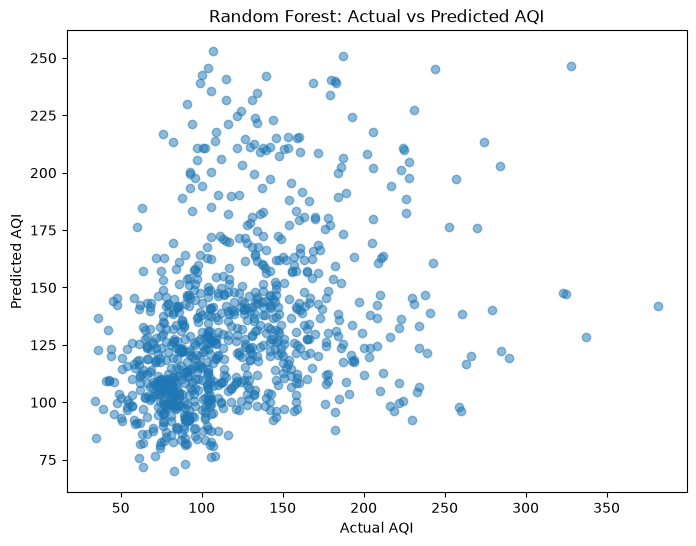

In [291]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Random Forest: Actual vs Predicted AQI")

plt.show()

In [292]:
correlation = model_df[
    [
        "aqi_value",
        "fireCount",
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "wind_speed_10m_max",
        "surface_pressure_mean"
    ]
].corr()

print(correlation["aqi_value"].sort_values(ascending=False))

aqi_value                    1.000000
surface_pressure_mean        0.327607
fireCount                    0.273269
relative_humidity_2m_mean   -0.043169
wind_speed_10m_max          -0.074085
precipitation_sum           -0.180763
temperature_2m_max          -0.205952
temperature_2m_mean         -0.285157
temperature_2m_min          -0.350847
Name: aqi_value, dtype: float64


In [293]:
print("AQI vs Fire correlation:",
      round(model_df["aqi_value"].corr(model_df["fireCount"]), 3))

AQI vs Fire correlation: 0.273


In [294]:
print(model_df["aqi_value"].describe())

count    4500.000000
mean      120.696000
std        59.333091
min        19.000000
25%        78.000000
50%       107.000000
75%       150.000000
max       408.000000
Name: aqi_value, dtype: float64


In [295]:
print(
    "AQI > 200:",
    (model_df["aqi_value"] > 200).sum()
)

print(
    "AQI > 300:",
    (model_df["aqi_value"] > 300).sum()
)

AQI > 200: 471
AQI > 300: 55


In [296]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(15))

                                 feature  importance
19                numerical__day_of_year    0.453590
14  numerical__relative_humidity_2m_mean    0.076456
12         numerical__temperature_2m_max    0.066620
17      numerical__surface_pressure_mean    0.062719
13         numerical__temperature_2m_min    0.054465
11        numerical__temperature_2m_mean    0.053241
16         numerical__wind_speed_10m_max    0.052966
10                  numerical__fireCount    0.035132
20                       numerical__year    0.023331
3             categorical__area_Ludhiana    0.023094
15          numerical__precipitation_sum    0.022783
1             categorical__area_Bathinda    0.016747
4              categorical__area_Patiala    0.015046
5             categorical__area_Rupnagar    0.012560
18                      numerical__month    0.009911


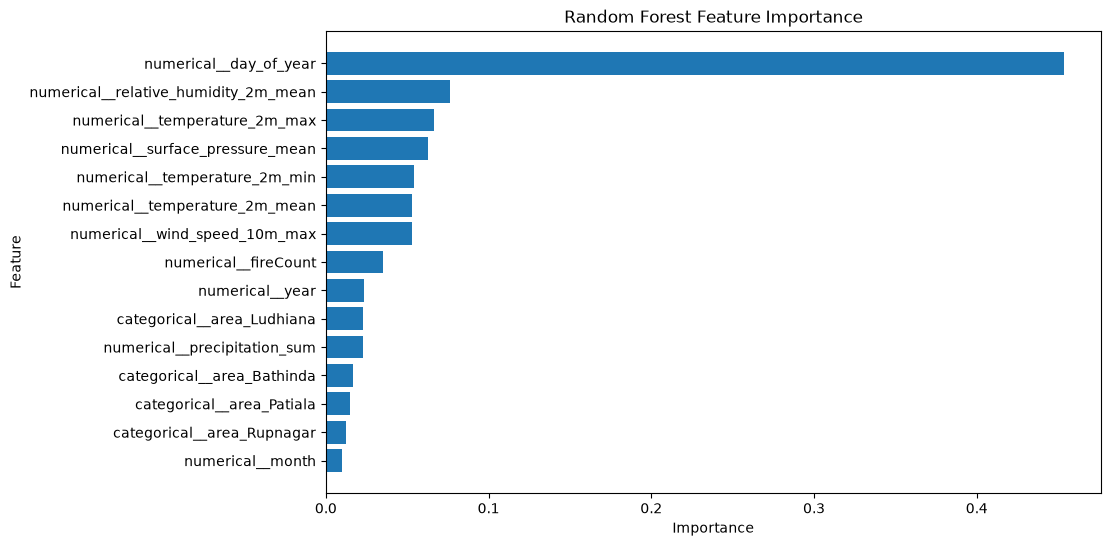

In [297]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(15).sort_values("importance")

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [298]:
X_train_no_doy = X_train.drop(columns=["day_of_year"])
X_test_no_doy = X_test.drop(columns=["day_of_year"])

In [299]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features_no_doy = [
    "area",
    "season"
]

numerical_features_no_doy = [
    "fireCount",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "month",
    "year"
]

preprocessor_no_doy = ColumnTransformer(
    transformers=[
        (
            "numerical",
            "passthrough",
            numerical_features_no_doy
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_no_doy
        )
    ]
)

In [300]:
X_train_no_doy_processed = preprocessor_no_doy.fit_transform(
    X_train_no_doy
)

X_test_no_doy_processed = preprocessor_no_doy.transform(
    X_test_no_doy
)

print(
    "Processed X_train shape:",
    X_train_no_doy_processed.shape
)

print(
    "Processed X_test shape:",
    X_test_no_doy_processed.shape
)

Processed X_train shape: (3602, 20)
Processed X_test shape: (898, 20)


In [301]:
rf_no_doy = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_no_doy.fit(
    X_train_no_doy_processed,
    y_train
)

y_pred_no_doy = rf_no_doy.predict(
    X_test_no_doy_processed
)

In [302]:
mae_no_doy = mean_absolute_error(
    y_test,
    y_pred_no_doy
)

rmse_no_doy = np.sqrt(
    mean_squared_error(y_test, y_pred_no_doy)
)

r2_no_doy = r2_score(
    y_test,
    y_pred_no_doy
)

print("Random Forest - Without day_of_year")
print("-----------------------------------")
print("MAE :", round(mae_no_doy, 2))
print("RMSE:", round(rmse_no_doy, 2))
print("R²  :", round(r2_no_doy, 4))

Random Forest - Without day_of_year
-----------------------------------
MAE : 40.07
RMSE: 52.64
R²  : -0.1525


In [303]:
import xgboost
print(xgboost.__version__)

3.4.1


In [304]:
from xgboost import XGBRegressor

In [305]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(
    X_train_processed,
    y_train
)

y_pred_xgb = xgb_model.predict(
    X_test_processed
)

In [306]:
xgb_mae = mean_absolute_error(
    y_test,
    y_pred_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

xgb_r2 = r2_score(
    y_test,
    y_pred_xgb
)

print("XGBoost")
print("-------")
print("MAE :", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R²  :", round(xgb_r2, 4))

XGBoost
-------
MAE : 38.26
RMSE: 50.48
R²  : -0.0598


In [307]:
# ============================================================
# FIRE DATE CONTINUITY CHECK
# ============================================================

target_areas = [
    "Amritsar",
    "Bathinda",
    "Jalandhar",
    "Ludhiana",
    "Patiala",
    "Rupnagar"
]

# Make sure date is datetime
model_df["date"] = pd.to_datetime(model_df["date"])

for area in target_areas:
    area_df = (
        model_df[model_df["area"] == area]
        [["date", "fireCount"]]
        .drop_duplicates()
        .sort_values("date")
    )

    # Difference between consecutive calendar dates
    date_diff = area_df["date"].diff().dt.days.dropna()

    gaps = date_diff[date_diff > 1]

    print(f"\n{'=' * 50}")
    print(f"Area: {area}")
    print(f"Rows: {len(area_df)}")
    print(f"Date range: {area_df['date'].min().date()} → {area_df['date'].max().date()}")
    print(f"Number of gaps: {len(gaps)}")

    if len(gaps) > 0:
        print("Gap sizes:")
        print(gaps.value_counts().sort_index())

        print("\nFirst few gaps:")
        print(gaps.head(10))
    else:
        print("No calendar-date gaps.")


Area: Amritsar
Rows: 730
Date range: 2022-04-01 → 2024-06-05
Number of gaps: 48
Gap sizes:
date
2.0    38
3.0     6
4.0     2
5.0     1
8.0     1
Name: count, dtype: int64

First few gaps:
350    2.0
384    3.0
429    2.0
582    2.0
719    3.0
777    5.0
859    3.0
895    2.0
965    2.0
972    2.0
Name: date, dtype: float64

Area: Bathinda
Rows: 705
Date range: 2022-04-01 → 2024-06-05
Number of gaps: 60
Gap sizes:
date
2.0     46
3.0      7
4.0      2
5.0      4
11.0     1
Name: count, dtype: int64

First few gaps:
42     2.0
64     2.0
142    2.0
297    2.0
317    2.0
430    3.0
464    2.0
643    3.0
720    2.0
802    2.0
Name: date, dtype: float64

Area: Jalandhar
Rows: 780
Date range: 2022-04-01 → 2024-06-05
Number of gaps: 16
Gap sizes:
date
2.0    15
3.0     1
Name: count, dtype: int64

First few gaps:
652     2.0
785     2.0
1595    2.0
2502    2.0
2654    2.0
2719    2.0
2738    3.0
3142    2.0
3169    2.0
3724    2.0
Name: date, dtype: float64

Area: Ludhiana
Rows: 785
Date ra

In [308]:
# ============================================================
# CREATE LEAKAGE-SAFE FIRE LAG FEATURES
# ============================================================

fire_lag_df = model_df[["date", "area", "fireCount"]].copy()

fire_lag_df["date"] = pd.to_datetime(fire_lag_df["date"])

fire_lag_df = fire_lag_df.sort_values(
    ["area", "date"]
).reset_index(drop=True)

# Create exact calendar-date lookup
fire_lookup = fire_lag_df.set_index(
    ["area", "date"]
)["fireCount"]

# Exact previous calendar-day features
for days in [1, 3, 7]:
    lag_dates = fire_lag_df["date"] - pd.Timedelta(days=days)

    fire_lag_df[f"fire_lag_{days}d"] = [
        fire_lookup.get((area, lag_date), np.nan)
        for area, lag_date in zip(
            fire_lag_df["area"],
            lag_dates
        )
    ]

# Keep only the new features
fire_lag_features = fire_lag_df[
    ["date", "area", "fire_lag_1d", "fire_lag_3d", "fire_lag_7d"]
].copy()

fire_lag_features.head(10)

,date,area,fire_lag_1d,fire_lag_3d,fire_lag_7d
0,2022-04-01,Amritsar,NaN,NaN,NaN
1,2022-04-02,Amritsar,0.0,NaN,NaN
2,2022-04-03,Amritsar,0.0,NaN,NaN
3,2022-04-04,Amritsar,1.0,0.0,NaN
4,2022-04-05,Amritsar,0.0,0.0,NaN
5,2022-04-06,Amritsar,0.0,1.0,NaN
6,2022-04-07,Amritsar,0.0,0.0,NaN
7,2022-04-08,Amritsar,0.0,0.0,0.0
8,2022-04-09,Amritsar,0.0,0.0,0.0
9,2022-04-10,Amritsar,0.0,0.0,1.0


In [309]:
# ============================================================
# CREATE LEAKAGE-SAFE FIRE ROLLING FEATURES
# ============================================================

rolling_df = model_df[["date", "area", "fireCount"]].copy()

rolling_df["date"] = pd.to_datetime(rolling_df["date"])

rolling_df = rolling_df.sort_values(
    ["area", "date"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Calculate rolling features separately for each area
# ------------------------------------------------------------

rolling_df["fire_rolling_3d"] = np.nan
rolling_df["fire_rolling_7d"] = np.nan
rolling_df["fire_rolling_14d"] = np.nan


for area in rolling_df["area"].unique():

    mask = rolling_df["area"] == area

    temp = rolling_df.loc[mask, ["date", "fireCount"]].copy()

    temp = temp.sort_values("date").set_index("date")

    # Exclude today's fireCount
    temp["fire_rolling_3d"] = (
        temp["fireCount"]
        .rolling("3D", closed="left")
        .sum()
    )

    temp["fire_rolling_7d"] = (
        temp["fireCount"]
        .rolling("7D", closed="left")
        .sum()
    )

    temp["fire_rolling_14d"] = (
        temp["fireCount"]
        .rolling("14D", closed="left")
        .sum()
    )

    # Put calculated values back into original dataframe
    rolling_df.loc[mask, "fire_rolling_3d"] = (
        temp["fire_rolling_3d"].values
    )

    rolling_df.loc[mask, "fire_rolling_7d"] = (
        temp["fire_rolling_7d"].values
    )

    rolling_df.loc[mask, "fire_rolling_14d"] = (
        temp["fire_rolling_14d"].values
    )


# ------------------------------------------------------------
# Keep only required columns
# ------------------------------------------------------------

rolling_features = rolling_df[
    [
        "date",
        "area",
        "fire_rolling_3d",
        "fire_rolling_7d",
        "fire_rolling_14d"
    ]
].copy()


rolling_features.head(15)

,date,area,fire_rolling_3d,fire_rolling_7d,fire_rolling_14d
0,2022-04-01,Amritsar,NaN,NaN,NaN
1,2022-04-02,Amritsar,0.0,0.0,0.0
2,2022-04-03,Amritsar,0.0,0.0,0.0
3,2022-04-04,Amritsar,1.0,1.0,1.0
4,2022-04-05,Amritsar,1.0,1.0,1.0
5,2022-04-06,Amritsar,1.0,1.0,1.0
6,2022-04-07,Amritsar,0.0,1.0,1.0
7,2022-04-08,Amritsar,0.0,1.0,1.0
8,2022-04-09,Amritsar,0.0,1.0,1.0
9,2022-04-10,Amritsar,0.0,1.0,1.0


In [310]:
# ============================================================
# MERGE FIRE LAG + ROLLING FEATURES INTO MODEL DATASET
# ============================================================

# Start from existing model_df
model_df_features = model_df.copy()

model_df_features["date"] = pd.to_datetime(
    model_df_features["date"]
)

# Merge lag features
model_df_features = model_df_features.merge(
    fire_lag_features,
    on=["date", "area"],
    how="left"
)

# Merge rolling features
model_df_features = model_df_features.merge(
    rolling_features,
    on=["date", "area"],
    how="left"
)

print("Shape:", model_df_features.shape)

print("\nNew fire features:")
print([
    "fire_lag_1d",
    "fire_lag_3d",
    "fire_lag_7d",
    "fire_rolling_3d",
    "fire_rolling_7d",
    "fire_rolling_14d"
])

print("\nMissing values:")
print(
    model_df_features[
        [
            "fire_lag_1d",
            "fire_lag_3d",
            "fire_lag_7d",
            "fire_rolling_3d",
            "fire_rolling_7d",
            "fire_rolling_14d"
        ]
    ].isna().sum()
)

model_df_features.head()

Shape: (4500, 21)

New fire features:
['fire_lag_1d', 'fire_lag_3d', 'fire_lag_7d', 'fire_rolling_3d', 'fire_rolling_7d', 'fire_rolling_14d']

Missing values:
fire_lag_1d         204
fire_lag_3d         252
fire_lag_7d         288
fire_rolling_3d      22
fire_rolling_7d       9
fire_rolling_14d      6
dtype: int64


,date,area,aqi_value,fireCount,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,wind_speed_10m_max,...,month,day_of_year,year,season,fire_lag_1d,fire_lag_3d,fire_lag_7d,fire_rolling_3d,fire_rolling_7d,fire_rolling_14d
0,2022-04-01,Amritsar,101.0,0.0,25.2,33.2,17.5,40,0.0,11.5,...,4,91,2022,Summer,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-04-01,Bathinda,60.0,0.0,27.8,36.0,18.8,25,0.0,16.6,...,4,91,2022,Summer,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-04-01,Jalandhar,117.0,0.0,23.4,32.1,14.6,51,0.0,12.5,...,4,91,2022,Summer,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-04-01,Ludhiana,126.0,0.0,25.8,34.8,17.5,35,0.0,15.1,...,4,91,2022,Summer,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-04-01,Patiala,130.0,0.0,27.4,36.4,19.3,30,0.0,17.9,...,4,91,2022,Summer,NaN,NaN,NaN,NaN,NaN,NaN


In [311]:
# ============================================================
# CHECK FIRE DATA FOR TARGET AREAS
# ============================================================

target_areas = [
    "Amritsar",
    "Bathinda",
    "Jalandhar",
    "Ludhiana",
    "Patiala",
    "Rupnagar"
]

fire_history = fire_clean[
    fire_clean["District"].isin(target_areas)
].copy()

fire_history["Date"] = pd.to_datetime(fire_history["Date"])

fire_history = fire_history[
    (fire_history["Date"] >= "2022-04-01") &
    (fire_history["Date"] <= "2024-06-05")
].copy()

print("Shape:", fire_history.shape)

for area in target_areas:
    area_df = fire_history[
        fire_history["District"] == area
    ].sort_values("Date")

    date_diff = area_df["Date"].diff().dt.days.dropna()
    gaps = date_diff[date_diff > 1]

    print(
        f"{area}: "
        f"{len(area_df)} rows | "
        f"gaps = {len(gaps)}"
    )

Shape: (4764, 5)
Amritsar: 794 rows | gaps = 3
Bathinda: 794 rows | gaps = 3
Jalandhar: 794 rows | gaps = 3
Ludhiana: 794 rows | gaps = 3
Patiala: 794 rows | gaps = 3
Rupnagar: 794 rows | gaps = 3


In [312]:
# ============================================================
# INSPECT MISSING DATES IN ACTUAL FIRE DATA
# ============================================================

for area in target_areas:

    area_df = (
        fire_history[fire_history["District"] == area]
        .sort_values("Date")
    )

    expected_dates = pd.date_range(
        start="2022-04-01",
        end="2024-06-05",
        freq="D"
    )

    actual_dates = pd.DatetimeIndex(area_df["Date"])

    missing_dates = expected_dates.difference(actual_dates)

    print(f"\n{'=' * 50}")
    print(f"Area: {area}")
    print(f"Missing dates ({len(missing_dates)}):")

    for d in missing_dates:
        print(d.date())


Area: Amritsar
Missing dates (3):
2024-02-28
2024-04-28
2024-05-28

Area: Bathinda
Missing dates (3):
2024-02-28
2024-04-28
2024-05-28

Area: Jalandhar
Missing dates (3):
2024-02-28
2024-04-28
2024-05-28

Area: Ludhiana
Missing dates (3):
2024-02-28
2024-04-28
2024-05-28

Area: Patiala
Missing dates (3):
2024-02-28
2024-04-28
2024-05-28

Area: Rupnagar
Missing dates (3):
2024-02-28
2024-04-28
2024-05-28


In [313]:
# ============================================================
# FINAL FIRE LAG + ROLLING FEATURES
# Built from actual fire history
# ============================================================

fire_features = fire_history[
    ["Date", "District", "fireCount"]
].copy()

fire_features = fire_features.rename(
    columns={
        "Date": "date",
        "District": "area"
    }
)

fire_features["date"] = pd.to_datetime(
    fire_features["date"]
)

fire_features = fire_features.sort_values(
    ["area", "date"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 1. EXACT CALENDAR-DAY LAG FEATURES
# ------------------------------------------------------------

fire_lookup = fire_features.set_index(
    ["area", "date"]
)["fireCount"]


for days in [1, 3, 7]:

    previous_dates = (
        fire_features["date"]
        - pd.Timedelta(days=days)
    )

    fire_features[f"fire_lag_{days}d"] = [
        fire_lookup.get(
            (area, previous_date),
            np.nan
        )
        for area, previous_date in zip(
            fire_features["area"],
            previous_dates
        )
    ]


# ------------------------------------------------------------
# 2. PAST FIRE ROLLING FEATURES
# ------------------------------------------------------------

fire_features["fire_rolling_3d"] = np.nan
fire_features["fire_rolling_7d"] = np.nan
fire_features["fire_rolling_14d"] = np.nan


for area in fire_features["area"].unique():

    mask = fire_features["area"] == area

    temp = fire_features.loc[
        mask,
        ["date", "fireCount"]
    ].copy()

    temp = (
        temp
        .sort_values("date")
        .set_index("date")
    )

    # Exclude today's fireCount
    temp["fire_rolling_3d"] = (
        temp["fireCount"]
        .rolling("3D", closed="left")
        .sum()
    )

    temp["fire_rolling_7d"] = (
        temp["fireCount"]
        .rolling("7D", closed="left")
        .sum()
    )

    temp["fire_rolling_14d"] = (
        temp["fireCount"]
        .rolling("14D", closed="left")
        .sum()
    )

    fire_features.loc[
        mask,
        "fire_rolling_3d"
    ] = temp["fire_rolling_3d"].values

    fire_features.loc[
        mask,
        "fire_rolling_7d"
    ] = temp["fire_rolling_7d"].values

    fire_features.loc[
        mask,
        "fire_rolling_14d"
    ] = temp["fire_rolling_14d"].values


# ------------------------------------------------------------
# 3. CHECK RESULT
# ------------------------------------------------------------

feature_columns = [
    "fire_lag_1d",
    "fire_lag_3d",
    "fire_lag_7d",
    "fire_rolling_3d",
    "fire_rolling_7d",
    "fire_rolling_14d"
]

print("Shape:", fire_features.shape)

print("\nMissing values:")
print(
    fire_features[feature_columns].isna().sum()
)

print("\nSample:")
print(
    fire_features[
        ["date", "area", "fireCount"] + feature_columns
    ].head(15)
)

Shape: (4764, 9)

Missing values:
fire_lag_1d         24
fire_lag_3d         36
fire_lag_7d         60
fire_rolling_3d      6
fire_rolling_7d      6
fire_rolling_14d     6
dtype: int64

Sample:
         date      area  fireCount  fire_lag_1d  fire_lag_3d  fire_lag_7d  \
0  2022-04-01  Amritsar        0.0          NaN          NaN          NaN   
1  2022-04-02  Amritsar        0.0          0.0          NaN          NaN   
2  2022-04-03  Amritsar        1.0          0.0          NaN          NaN   
3  2022-04-04  Amritsar        0.0          1.0          0.0          NaN   
4  2022-04-05  Amritsar        0.0          0.0          0.0          NaN   
5  2022-04-06  Amritsar        0.0          0.0          1.0          NaN   
6  2022-04-07  Amritsar        0.0          0.0          0.0          NaN   
7  2022-04-08  Amritsar        0.0          0.0          0.0          0.0   
8  2022-04-09  Amritsar        0.0          0.0          0.0          0.0   
9  2022-04-10  Amritsar        0.0  

In [314]:
# ============================================================
# MERGE FINAL FIRE FEATURES INTO MODEL DATASET
# ============================================================

model_df_fire = model_df.copy()

model_df_fire["date"] = pd.to_datetime(
    model_df_fire["date"]
)

# Select only the required fire features
fire_feature_columns = [
    "date",
    "area",
    "fire_lag_1d",
    "fire_lag_3d",
    "fire_lag_7d",
    "fire_rolling_3d",
    "fire_rolling_7d",
    "fire_rolling_14d"
]

fire_features_for_merge = fire_features[
    fire_feature_columns
].copy()


# Merge with AQI + weather dataset
model_df_fire = model_df_fire.merge(
    fire_features_for_merge,
    on=["date", "area"],
    how="left"
)


# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

print("Shape:", model_df_fire.shape)

print("\nExpected rows:", len(model_df))
print("Actual rows:", len(model_df_fire))

print("\nMissing values in new features:")
print(
    model_df_fire[
        fire_feature_columns[2:]
    ].isna().sum()
)

print("\nNew columns:")
print(model_df_fire.columns.tolist())

Shape: (4500, 21)

Expected rows: 4500
Actual rows: 4500

Missing values in new features:
fire_lag_1d         24
fire_lag_3d         36
fire_lag_7d         58
fire_rolling_3d      6
fire_rolling_7d      6
fire_rolling_14d     6
dtype: int64

New columns:
['date', 'area', 'aqi_value', 'fireCount', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'surface_pressure_mean', 'month', 'day_of_year', 'year', 'season', 'fire_lag_1d', 'fire_lag_3d', 'fire_lag_7d', 'fire_rolling_3d', 'fire_rolling_7d', 'fire_rolling_14d']


In [315]:
# ============================================================
# XGBOOST WITH FIRE LAG + ROLLING FEATURES
# ============================================================

# Make sure chronological order is maintained
model_df_fire = (
    model_df_fire
    .sort_values("date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 1. SAME CHRONOLOGICAL TRAIN / TEST SPLIT
# ------------------------------------------------------------

split_date = model_df_fire["date"].quantile(0.80)

train_fire = model_df_fire[
    model_df_fire["date"] <= split_date
].copy()

test_fire = model_df_fire[
    model_df_fire["date"] > split_date
].copy()

print("Split date:", split_date.date())

print("\nTrain:")
print(len(train_fire))
print(train_fire["date"].min().date(), "→", train_fire["date"].max().date())

print("\nTest:")
print(len(test_fire))
print(test_fire["date"].min().date(), "→", test_fire["date"].max().date())


# ------------------------------------------------------------
# 2. FEATURES / TARGET
# ------------------------------------------------------------

y_train_fire = train_fire["aqi_value"]
y_test_fire = test_fire["aqi_value"]

X_train_fire = train_fire.drop(
    columns=["aqi_value", "date"]
)

X_test_fire = test_fire.drop(
    columns=["aqi_value", "date"]
)


# ------------------------------------------------------------
# 3. FEATURE TYPES
# ------------------------------------------------------------

categorical_features_fire = [
    "area",
    "season"
]

numerical_features_fire = [
    "fireCount",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "month",
    "day_of_year",
    "year",

    # NEW FIRE HISTORY FEATURES
    "fire_lag_1d",
    "fire_lag_3d",
    "fire_lag_7d",
    "fire_rolling_3d",
    "fire_rolling_7d",
    "fire_rolling_14d"
]


# ------------------------------------------------------------
# 4. PREPROCESSOR
# ------------------------------------------------------------

preprocessor_fire = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_fire
        ),
        (
            "numerical",
            "passthrough",
            numerical_features_fire
        )
    ]
)


# Fit ONLY on training data
X_train_fire_processed = preprocessor_fire.fit_transform(
    X_train_fire
)

X_test_fire_processed = preprocessor_fire.transform(
    X_test_fire
)


print("\nProcessed shapes:")
print("X_train:", X_train_fire_processed.shape)
print("X_test :", X_test_fire_processed.shape)


# ------------------------------------------------------------
# 5. XGBOOST
# SAME MODEL SETTINGS AS BASELINE
# ------------------------------------------------------------

xgb_fire_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)


# Train
xgb_fire_model.fit(
    X_train_fire_processed,
    y_train_fire
)


# Predict
y_pred_xgb_fire = xgb_fire_model.predict(
    X_test_fire_processed
)


# ------------------------------------------------------------
# 6. EVALUATION
# ------------------------------------------------------------

mae_xgb_fire = mean_absolute_error(
    y_test_fire,
    y_pred_xgb_fire
)

rmse_xgb_fire = np.sqrt(
    mean_squared_error(
        y_test_fire,
        y_pred_xgb_fire
    )
)

r2_xgb_fire = r2_score(
    y_test_fire,
    y_pred_xgb_fire
)


print("\n" + "=" * 50)
print("XGBOOST + FIRE LAG/ROLLING FEATURES")
print("=" * 50)

print(f"MAE  = {mae_xgb_fire:.4f}")
print(f"RMSE = {rmse_xgb_fire:.4f}")
print(f"R²   = {r2_xgb_fire:.4f}")


# ------------------------------------------------------------
# 7. COMPARE WITH BASELINE
# ------------------------------------------------------------

print("\n" + "=" * 50)
print("COMPARISON WITH BASELINE")
print("=" * 50)

print(f"Baseline MAE  : 38.26")
print(f"New MAE       : {mae_xgb_fire:.4f}")

print(f"\nBaseline RMSE : 50.48")
print(f"New RMSE      : {rmse_xgb_fire:.4f}")

print(f"\nBaseline R²   : -0.0598")
print(f"New R²        : {r2_xgb_fire:.4f}")

Split date: 2023-12-29

Train:
3602
2022-04-01 → 2023-12-29

Test:
898
2023-12-30 → 2024-06-05

Processed shapes:
X_train: (3602, 27)
X_test : (898, 27)

XGBOOST + FIRE LAG/ROLLING FEATURES
MAE  = 38.8748
RMSE = 51.1350
R²   = -0.0875

COMPARISON WITH BASELINE
Baseline MAE  : 38.26
New MAE       : 38.8748

Baseline RMSE : 50.48
New RMSE      : 51.1350

Baseline R²   : -0.0598
New R²        : -0.0875


In [316]:
# ============================================================
# AQI TEMPORAL FEATURES - FIRST CHECK
# ============================================================

aqi_forecast_df = model_df.copy()

aqi_forecast_df["date"] = pd.to_datetime(
    aqi_forecast_df["date"]
)

aqi_forecast_df = (
    aqi_forecast_df
    .sort_values(["area", "date"])
    .reset_index(drop=True)
)

print("Shape:", aqi_forecast_df.shape)

for area in aqi_forecast_df["area"].unique():

    area_df = aqi_forecast_df[
        aqi_forecast_df["area"] == area
    ].sort_values("date")

    date_diff = (
        area_df["date"]
        .diff()
        .dt.days
        .dropna()
    )

    gaps = date_diff[date_diff > 1]

    print(
        f"{area}: "
        f"{len(area_df)} rows | "
        f"gaps = {len(gaps)}"
    )

Shape: (4500, 15)
Amritsar: 730 rows | gaps = 48
Bathinda: 705 rows | gaps = 60
Jalandhar: 780 rows | gaps = 16
Ludhiana: 785 rows | gaps = 12
Patiala: 784 rows | gaps = 13
Rupnagar: 716 rows | gaps = 49


In [317]:
# ============================================================
# AQI LAG + ROLLING FEATURES
# ============================================================

aqi_features = aqi_forecast_df[
    ["date", "area", "aqi_value"]
].copy()

aqi_features = aqi_features.sort_values(
    ["area", "date"]
).reset_index(drop=True)


# ------------------------------------------------------------
# EXACT CALENDAR-DAY AQI LAGS
# ------------------------------------------------------------

aqi_lookup = aqi_features.set_index(
    ["area", "date"]
)["aqi_value"]


for days in [1, 3, 7]:

    previous_dates = (
        aqi_features["date"]
        - pd.Timedelta(days=days)
    )

    aqi_features[f"aqi_lag_{days}d"] = [
        aqi_lookup.get(
            (area, previous_date),
            np.nan
        )
        for area, previous_date in zip(
            aqi_features["area"],
            previous_dates
        )
    ]


# ------------------------------------------------------------
# PAST-ONLY ROLLING AQI
# ------------------------------------------------------------

aqi_features["aqi_rolling_3d"] = np.nan
aqi_features["aqi_rolling_7d"] = np.nan
aqi_features["aqi_rolling_14d"] = np.nan


for area in aqi_features["area"].unique():

    mask = aqi_features["area"] == area

    temp = aqi_features.loc[
        mask,
        ["date", "aqi_value"]
    ].copy()

    temp = (
        temp
        .sort_values("date")
        .set_index("date")
    )

    # IMPORTANT:
    # closed="left" excludes today's AQI

    temp["aqi_rolling_3d"] = (
        temp["aqi_value"]
        .rolling("3D", closed="left")
        .mean()
    )

    temp["aqi_rolling_7d"] = (
        temp["aqi_value"]
        .rolling("7D", closed="left")
        .mean()
    )

    temp["aqi_rolling_14d"] = (
        temp["aqi_value"]
        .rolling("14D", closed="left")
        .mean()
    )

    aqi_features.loc[
        mask,
        "aqi_rolling_3d"
    ] = temp["aqi_rolling_3d"].values

    aqi_features.loc[
        mask,
        "aqi_rolling_7d"
    ] = temp["aqi_rolling_7d"].values

    aqi_features.loc[
        mask,
        "aqi_rolling_14d"
    ] = temp["aqi_rolling_14d"].values


# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

aqi_temporal_columns = [
    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d",
    "aqi_rolling_3d",
    "aqi_rolling_7d",
    "aqi_rolling_14d"
]

print("Shape:", aqi_features.shape)

print("\nMissing values:")
print(
    aqi_features[aqi_temporal_columns].isna().sum()
)

print("\nSample:")
print(
    aqi_features[
        ["date", "area", "aqi_value"] +
        aqi_temporal_columns
    ].head(15)
)

Shape: (4500, 9)

Missing values:
aqi_lag_1d         204
aqi_lag_3d         252
aqi_lag_7d         288
aqi_rolling_3d      22
aqi_rolling_7d       9
aqi_rolling_14d      6
dtype: int64

Sample:
         date      area  aqi_value  aqi_lag_1d  aqi_lag_3d  aqi_lag_7d  \
0  2022-04-01  Amritsar      101.0         NaN         NaN         NaN   
1  2022-04-02  Amritsar      116.0       101.0         NaN         NaN   
2  2022-04-03  Amritsar       97.0       116.0         NaN         NaN   
3  2022-04-04  Amritsar      121.0        97.0       101.0         NaN   
4  2022-04-05  Amritsar      111.0       121.0       116.0         NaN   
5  2022-04-06  Amritsar      112.0       111.0        97.0         NaN   
6  2022-04-07  Amritsar      138.0       112.0       121.0         NaN   
7  2022-04-08  Amritsar      143.0       138.0       111.0       101.0   
8  2022-04-09  Amritsar      143.0       143.0       112.0       116.0   
9  2022-04-10  Amritsar      112.0       143.0       138.0        

In [318]:
# ============================================================
# XGBOOST WITH HISTORICAL AQI LAG FEATURES
# ============================================================

# Start from original model_df
model_df_aqi = model_df.copy()

model_df_aqi["date"] = pd.to_datetime(
    model_df_aqi["date"]
)

# Merge only AQI lag features
aqi_lag_columns = [
    "date",
    "area",
    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d"
]

model_df_aqi = model_df_aqi.merge(
    aqi_features[aqi_lag_columns],
    on=["date", "area"],
    how="left"
)

# Sort chronologically
model_df_aqi = (
    model_df_aqi
    .sort_values("date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 1. SAME 80/20 CHRONOLOGICAL SPLIT
# ------------------------------------------------------------

split_date_aqi = model_df_aqi["date"].quantile(0.80)

train_aqi = model_df_aqi[
    model_df_aqi["date"] <= split_date_aqi
].copy()

test_aqi = model_df_aqi[
    model_df_aqi["date"] > split_date_aqi
].copy()

print("Split date:", split_date_aqi.date())

print("\nTrain:", len(train_aqi))
print("Test :", len(test_aqi))


# ------------------------------------------------------------
# 2. X / Y
# ------------------------------------------------------------

y_train_aqi = train_aqi["aqi_value"]
y_test_aqi = test_aqi["aqi_value"]

X_train_aqi = train_aqi.drop(
    columns=["aqi_value", "date"]
)

X_test_aqi = test_aqi.drop(
    columns=["aqi_value", "date"]
)


# ------------------------------------------------------------
# 3. FEATURES
# ------------------------------------------------------------

categorical_features_aqi = [
    "area",
    "season"
]

numerical_features_aqi = [
    "fireCount",

    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",

    "month",
    "day_of_year",
    "year",

    # NEW
    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d"
]


# ------------------------------------------------------------
# 4. PREPROCESSING
# ------------------------------------------------------------

preprocessor_aqi = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_aqi
        ),
        (
            "numerical",
            "passthrough",
            numerical_features_aqi
        )
    ]
)

X_train_aqi_processed = (
    preprocessor_aqi
    .fit_transform(X_train_aqi)
)

X_test_aqi_processed = (
    preprocessor_aqi
    .transform(X_test_aqi)
)

print("\nProcessed shapes:")
print(
    "X_train:",
    X_train_aqi_processed.shape
)

print(
    "X_test :",
    X_test_aqi_processed.shape
)


# ------------------------------------------------------------
# 5. XGBOOST
# SAME HYPERPARAMETERS AS BASELINE
# ------------------------------------------------------------

xgb_aqi_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_aqi_model.fit(
    X_train_aqi_processed,
    y_train_aqi
)


# ------------------------------------------------------------
# 6. PREDICTION
# ------------------------------------------------------------

y_pred_xgb_aqi = xgb_aqi_model.predict(
    X_test_aqi_processed
)


# ------------------------------------------------------------
# 7. EVALUATION
# ------------------------------------------------------------

mae_xgb_aqi = mean_absolute_error(
    y_test_aqi,
    y_pred_xgb_aqi
)

rmse_xgb_aqi = np.sqrt(
    mean_squared_error(
        y_test_aqi,
        y_pred_xgb_aqi
    )
)

r2_xgb_aqi = r2_score(
    y_test_aqi,
    y_pred_xgb_aqi
)


print("\n" + "=" * 55)
print("XGBOOST + AQI LAG FEATURES")
print("=" * 55)

print(f"MAE  = {mae_xgb_aqi:.4f}")
print(f"RMSE = {rmse_xgb_aqi:.4f}")
print(f"R²   = {r2_xgb_aqi:.4f}")


# ------------------------------------------------------------
# 8. BASELINE COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("BASELINE vs AQI-LAG MODEL")
print("=" * 55)

print(f"Baseline MAE : 38.26")
print(f"New MAE      : {mae_xgb_aqi:.4f}")

print(f"\nBaseline RMSE: 50.48")
print(f"New RMSE     : {rmse_xgb_aqi:.4f}")

print(f"\nBaseline R²  : -0.0598")
print(f"New R²       : {r2_xgb_aqi:.4f}")

Split date: 2023-12-29

Train: 3602
Test : 898

Processed shapes:
X_train: (3602, 24)
X_test : (898, 24)

XGBOOST + AQI LAG FEATURES
MAE  = 31.0691
RMSE = 41.2033
R²   = 0.2939

BASELINE vs AQI-LAG MODEL
Baseline MAE : 38.26
New MAE      : 31.0691

Baseline RMSE: 50.48
New RMSE     : 41.2033

Baseline R²  : -0.0598
New R²       : 0.2939


In [319]:
# ============================================================
# XGBOOST + AQI LAGS + AQI ROLLING FEATURES
# ============================================================

model_df_aqi_roll = model_df.copy()

model_df_aqi_roll["date"] = pd.to_datetime(
    model_df_aqi_roll["date"]
)

# Features to add
aqi_temporal_columns = [
    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d",
    "aqi_rolling_3d",
    "aqi_rolling_7d",
    "aqi_rolling_14d"
]

# Merge temporal AQI features
model_df_aqi_roll = model_df_aqi_roll.merge(
    aqi_features[
        ["date", "area"] + aqi_temporal_columns
    ],
    on=["date", "area"],
    how="left"
)

# Sort chronologically
model_df_aqi_roll = (
    model_df_aqi_roll
    .sort_values("date")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# SAME 80/20 CHRONOLOGICAL SPLIT
# ------------------------------------------------------------

split_date_roll = (
    model_df_aqi_roll["date"].quantile(0.80)
)

train_roll = model_df_aqi_roll[
    model_df_aqi_roll["date"] <= split_date_roll
].copy()

test_roll = model_df_aqi_roll[
    model_df_aqi_roll["date"] > split_date_roll
].copy()

print("Split date:", split_date_roll.date())
print("Train:", len(train_roll))
print("Test :", len(test_roll))


# ------------------------------------------------------------
# X / Y
# ------------------------------------------------------------

y_train_roll = train_roll["aqi_value"]
y_test_roll = test_roll["aqi_value"]

X_train_roll = train_roll.drop(
    columns=["aqi_value", "date"]
)

X_test_roll = test_roll.drop(
    columns=["aqi_value", "date"]
)


# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------

categorical_features_roll = [
    "area",
    "season"
]

numerical_features_roll = [
    "fireCount",

    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",

    "month",
    "day_of_year",
    "year",

    # AQI HISTORY
    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d",
    "aqi_rolling_3d",
    "aqi_rolling_7d",
    "aqi_rolling_14d"
]


# ------------------------------------------------------------
# PREPROCESSING
# ------------------------------------------------------------

preprocessor_roll = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_roll
        ),
        (
            "numerical",
            "passthrough",
            numerical_features_roll
        )
    ]
)

X_train_roll_processed = (
    preprocessor_roll.fit_transform(X_train_roll)
)

X_test_roll_processed = (
    preprocessor_roll.transform(X_test_roll)
)

print("\nProcessed shapes:")
print("X_train:", X_train_roll_processed.shape)
print("X_test :", X_test_roll_processed.shape)


# ------------------------------------------------------------
# XGBOOST
# ------------------------------------------------------------

xgb_roll_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_roll_model.fit(
    X_train_roll_processed,
    y_train_roll
)


# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

y_pred_xgb_roll = xgb_roll_model.predict(
    X_test_roll_processed
)


# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

mae_xgb_roll = mean_absolute_error(
    y_test_roll,
    y_pred_xgb_roll
)

rmse_xgb_roll = np.sqrt(
    mean_squared_error(
        y_test_roll,
        y_pred_xgb_roll
    )
)

r2_xgb_roll = r2_score(
    y_test_roll,
    y_pred_xgb_roll
)


print("\n" + "=" * 55)
print("XGBOOST + AQI LAGS + ROLLING")
print("=" * 55)

print(f"MAE  = {mae_xgb_roll:.4f}")
print(f"RMSE = {rmse_xgb_roll:.4f}")
print(f"R²   = {r2_xgb_roll:.4f}")


print("\n" + "=" * 55)
print("CURRENT CHAMPION")
print("=" * 55)

print("MAE  = 31.0691")
print("RMSE = 41.2033")
print("R²   = 0.2939")

Split date: 2023-12-29
Train: 3602
Test : 898

Processed shapes:
X_train: (3602, 27)
X_test : (898, 27)

XGBOOST + AQI LAGS + ROLLING
MAE  = 30.6604
RMSE = 40.4623
R²   = 0.3191

CURRENT CHAMPION
MAE  = 31.0691
RMSE = 41.2033
R²   = 0.2939


In [320]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE
# ============================================================

# Get feature names after preprocessing
feature_names = (
    preprocessor_roll
    .get_feature_names_out()
)

# Get XGBoost importance
importance_values = (
    xgb_roll_model
    .feature_importances_
)

# Create dataframe
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
})

# Sort highest first
feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 15 features:")
print(
    feature_importance_df.head(15)
)

Top 15 features:
                                 feature  importance
0                  numerical__aqi_lag_1d    0.295102
1              numerical__aqi_rolling_3d    0.095337
2              numerical__aqi_rolling_7d    0.067605
3             categorical__season_Summer    0.044449
4                 numerical__day_of_year    0.037453
5           numerical__precipitation_sum    0.034759
6                        numerical__year    0.030317
7             numerical__aqi_rolling_14d    0.029391
8            categorical__season_Monsoon    0.028361
9   numerical__relative_humidity_2m_mean    0.027718
10                  numerical__fireCount    0.025525
11         numerical__temperature_2m_max    0.024048
12         numerical__wind_speed_10m_max    0.023316
13                 numerical__aqi_lag_3d    0.023137
14         numerical__temperature_2m_min    0.022508


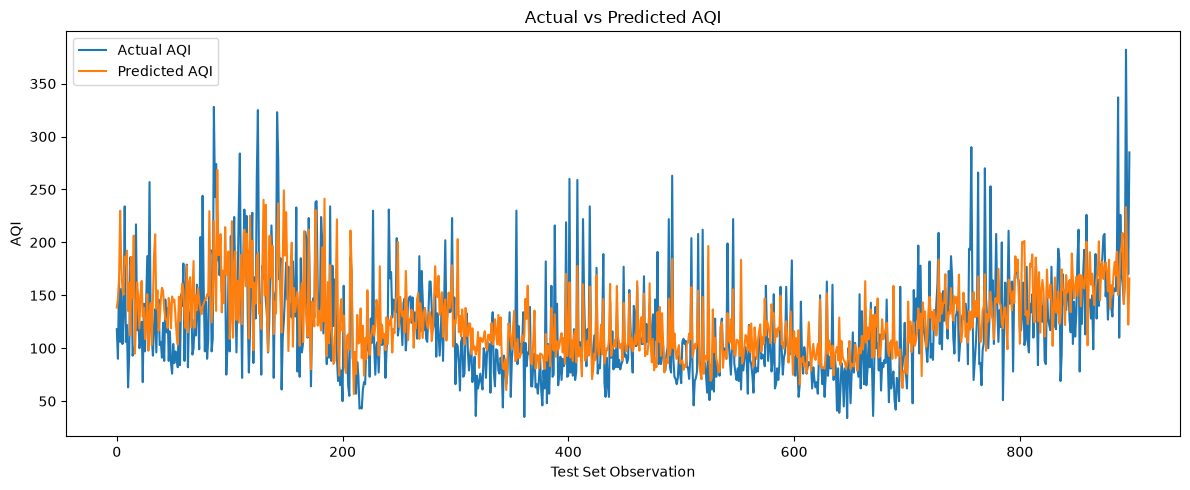

In [321]:
# ============================================================
# ACTUAL VS PREDICTED AQI
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_roll.values,
    label="Actual AQI"
)

plt.plot(
    y_pred_xgb_roll,
    label="Predicted AQI"
)

plt.title("Actual vs Predicted AQI")
plt.xlabel("Test Set Observation")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

In [322]:
# ============================================================
# ERROR ANALYSIS BY AQI RANGE
# ============================================================

error_df = pd.DataFrame({
    "actual": y_test_roll.values,
    "predicted": y_pred_xgb_roll
})

error_df["error"] = (
    error_df["actual"] -
    error_df["predicted"]
)

error_df["absolute_error"] = (
    error_df["error"].abs()
)


# ------------------------------------------------------------
# AQI RANGES
# ------------------------------------------------------------

def aqi_range(aqi):
    if aqi <= 50:
        return "Good (0-50)"
    elif aqi <= 100:
        return "Satisfactory (51-100)"
    elif aqi <= 200:
        return "Moderate (101-200)"
    elif aqi <= 300:
        return "Poor (201-300)"
    else:
        return "Very Poor/Severe (>300)"


error_df["aqi_range"] = (
    error_df["actual"].apply(aqi_range)
)


# ------------------------------------------------------------
# PERFORMANCE BY RANGE
# ------------------------------------------------------------

range_analysis = (
    error_df
    .groupby("aqi_range")
    .agg(
        samples=("actual", "count"),
        MAE=("absolute_error", "mean"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean")
    )
    .reset_index()
)

print(range_analysis)

                 aqi_range  samples         MAE  actual_mean  predicted_mean
0              Good (0-50)       20   57.253458    43.350000      100.603462
1       Moderate (101-200)      459   25.379550   136.788671      138.896606
2           Poor (201-300)       59   67.796143   231.322034      163.541016
3    Satisfactory (51-100)      355   28.269784    80.771831      107.132164
4  Very Poor/Severe (>300)        5  140.609946   339.000000      198.390045


In [323]:
# ============================================================
# AQI TREND FEATURES
# ============================================================

aqi_trend_features = aqi_features[
    [
        "date",
        "area",
        "aqi_lag_1d",
        "aqi_lag_3d",
        "aqi_lag_7d"
    ]
].copy()

# ------------------------------------------------------------
# Calculate past AQI trends
# ------------------------------------------------------------

aqi_trend_features["aqi_trend_3d"] = (
    aqi_trend_features["aqi_lag_1d"]
    - aqi_trend_features["aqi_lag_3d"]
)

aqi_trend_features["aqi_trend_7d"] = (
    aqi_trend_features["aqi_lag_1d"]
    - aqi_trend_features["aqi_lag_7d"]
)


# ------------------------------------------------------------
# Check
# ------------------------------------------------------------

print("Shape:", aqi_trend_features.shape)

print("\nMissing values:")
print(
    aqi_trend_features[
        ["aqi_trend_3d", "aqi_trend_7d"]
    ].isna().sum()
)

print("\nSample:")
print(
    aqi_trend_features[
        [
            "date",
            "area",
            "aqi_lag_1d",
            "aqi_lag_3d",
            "aqi_lag_7d",
            "aqi_trend_3d",
            "aqi_trend_7d"
        ]
    ].head(15)
)

Shape: (4500, 7)

Missing values:
aqi_trend_3d    422
aqi_trend_7d    464
dtype: int64

Sample:
         date      area  aqi_lag_1d  aqi_lag_3d  aqi_lag_7d  aqi_trend_3d  \
0  2022-04-01  Amritsar         NaN         NaN         NaN           NaN   
1  2022-04-02  Amritsar       101.0         NaN         NaN           NaN   
2  2022-04-03  Amritsar       116.0         NaN         NaN           NaN   
3  2022-04-04  Amritsar        97.0       101.0         NaN          -4.0   
4  2022-04-05  Amritsar       121.0       116.0         NaN           5.0   
5  2022-04-06  Amritsar       111.0        97.0         NaN          14.0   
6  2022-04-07  Amritsar       112.0       121.0         NaN          -9.0   
7  2022-04-08  Amritsar       138.0       111.0       101.0          27.0   
8  2022-04-09  Amritsar       143.0       112.0       116.0          31.0   
9  2022-04-10  Amritsar       143.0       138.0        97.0           5.0   
10 2022-04-11  Amritsar       112.0       143.0       121

In [324]:
# ============================================================
# XGBOOST + AQI LAGS + ROLLING + TREND FEATURES
# ============================================================

model_df_aqi_trend = model_df.copy()

model_df_aqi_trend["date"] = pd.to_datetime(
    model_df_aqi_trend["date"]
)

# ------------------------------------------------------------
# Merge all AQI temporal features
# ------------------------------------------------------------

aqi_temporal_columns = [
    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d",
    "aqi_rolling_3d",
    "aqi_rolling_7d",
    "aqi_rolling_14d",
    "aqi_trend_3d",
    "aqi_trend_7d"
]

model_df_aqi_trend = model_df_aqi_trend.merge(
    aqi_features[
        [
            "date",
            "area",
            "aqi_lag_1d",
            "aqi_lag_3d",
            "aqi_lag_7d",
            "aqi_rolling_3d",
            "aqi_rolling_7d",
            "aqi_rolling_14d"
        ]
    ],
    on=["date", "area"],
    how="left"
)

model_df_aqi_trend = model_df_aqi_trend.merge(
    aqi_trend_features[
        [
            "date",
            "area",
            "aqi_trend_3d",
            "aqi_trend_7d"
        ]
    ],
    on=["date", "area"],
    how="left"
)

# Sort chronologically
model_df_aqi_trend = (
    model_df_aqi_trend
    .sort_values("date")
    .reset_index(drop=True)
)

print("Shape:", model_df_aqi_trend.shape)


# ------------------------------------------------------------
# SAME CHRONOLOGICAL 80/20 SPLIT
# ------------------------------------------------------------

split_date_trend = (
    model_df_aqi_trend["date"].quantile(0.80)
)

train_trend = model_df_aqi_trend[
    model_df_aqi_trend["date"] <= split_date_trend
].copy()

test_trend = model_df_aqi_trend[
    model_df_aqi_trend["date"] > split_date_trend
].copy()

print("Split date:", split_date_trend.date())
print("Train:", len(train_trend))
print("Test :", len(test_trend))


# ------------------------------------------------------------
# X / Y
# ------------------------------------------------------------

y_train_trend = train_trend["aqi_value"]
y_test_trend = test_trend["aqi_value"]

X_train_trend = train_trend.drop(
    columns=["aqi_value", "date"]
)

X_test_trend = test_trend.drop(
    columns=["aqi_value", "date"]
)


# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------

categorical_features_trend = [
    "area",
    "season"
]

numerical_features_trend = [
    "fireCount",

    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",

    "month",
    "day_of_year",
    "year",

    # AQI HISTORY
    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d",

    # AQI ROLLING
    "aqi_rolling_3d",
    "aqi_rolling_7d",
    "aqi_rolling_14d",

    # AQI TREND
    "aqi_trend_3d",
    "aqi_trend_7d"
]


# ------------------------------------------------------------
# PREPROCESSING
# ------------------------------------------------------------

preprocessor_trend = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_trend
        ),
        (
            "numerical",
            "passthrough",
            numerical_features_trend
        )
    ]
)

X_train_trend_processed = (
    preprocessor_trend.fit_transform(X_train_trend)
)

X_test_trend_processed = (
    preprocessor_trend.transform(X_test_trend)
)

print("\nProcessed shapes:")
print(
    "X_train:",
    X_train_trend_processed.shape
)

print(
    "X_test :",
    X_test_trend_processed.shape
)


# ------------------------------------------------------------
# XGBOOST
# SAME HYPERPARAMETERS
# ------------------------------------------------------------

xgb_trend_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_trend_model.fit(
    X_train_trend_processed,
    y_train_trend
)


# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

y_pred_xgb_trend = xgb_trend_model.predict(
    X_test_trend_processed
)


# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

mae_xgb_trend = mean_absolute_error(
    y_test_trend,
    y_pred_xgb_trend
)

rmse_xgb_trend = np.sqrt(
    mean_squared_error(
        y_test_trend,
        y_pred_xgb_trend
    )
)

r2_xgb_trend = r2_score(
    y_test_trend,
    y_pred_xgb_trend
)


print("\n" + "=" * 60)
print("XGBOOST + AQI LAGS + ROLLING + TREND")
print("=" * 60)

print(f"MAE  = {mae_xgb_trend:.4f}")
print(f"RMSE = {rmse_xgb_trend:.4f}")
print(f"R²   = {r2_xgb_trend:.4f}")


# ------------------------------------------------------------
# CURRENT CHAMPION COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CURRENT CHAMPION")
print("=" * 60)

print("MAE  = 30.6604")
print("RMSE = 40.4623")
print("R²   = 0.3191")

Shape: (4500, 23)
Split date: 2023-12-29
Train: 3602
Test : 898

Processed shapes:
X_train: (3602, 29)
X_test : (898, 29)

XGBOOST + AQI LAGS + ROLLING + TREND
MAE  = 30.4217
RMSE = 40.5742
R²   = 0.3153

CURRENT CHAMPION
MAE  = 30.6604
RMSE = 40.4623
R²   = 0.3191


In [325]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost Baseline",
        "XGBoost + Fire Lag/Rolling",
        "XGBoost + AQI Lags",
        "XGBoost + AQI Lags + Rolling",
        "XGBoost + AQI Lags + Rolling + Trend"
    ],

    "MAE": [
        41.77,
        38.86,
        38.26,
        38.8748,
        31.0691,
        30.6604,
        30.4217
    ],

    "RMSE": [
        52.21,
        51.17,
        50.48,
        51.1350,
        41.2033,
        40.4623,
        40.5742
    ],

    "R2": [
        -0.1337,
        -0.0890,
        -0.0598,
        -0.0875,
        0.2939,
        0.3191,
        0.3153
    ]
})

print(final_results)

                                  Model      MAE     RMSE      R2
0                     Linear Regression  41.7700  52.2100 -0.1337
1                         Random Forest  38.8600  51.1700 -0.0890
2                      XGBoost Baseline  38.2600  50.4800 -0.0598
3            XGBoost + Fire Lag/Rolling  38.8748  51.1350 -0.0875
4                    XGBoost + AQI Lags  31.0691  41.2033  0.2939
5          XGBoost + AQI Lags + Rolling  30.6604  40.4623  0.3191
6  XGBoost + AQI Lags + Rolling + Trend  30.4217  40.5742  0.3153


In [326]:
# Sort by R²
final_results.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,RMSE,R2
5,XGBoost + AQI Lags + Rolling,30.6604,40.4623,0.3191
6,XGBoost + AQI Lags + Rolling + Trend,30.4217,40.5742,0.3153
4,XGBoost + AQI Lags,31.0691,41.2033,0.2939
2,XGBoost Baseline,38.2600,50.4800,-0.0598
3,XGBoost + Fire Lag/Rolling,38.8748,51.1350,-0.0875
1,Random Forest,38.8600,51.1700,-0.0890
0,Linear Regression,41.7700,52.2100,-0.1337


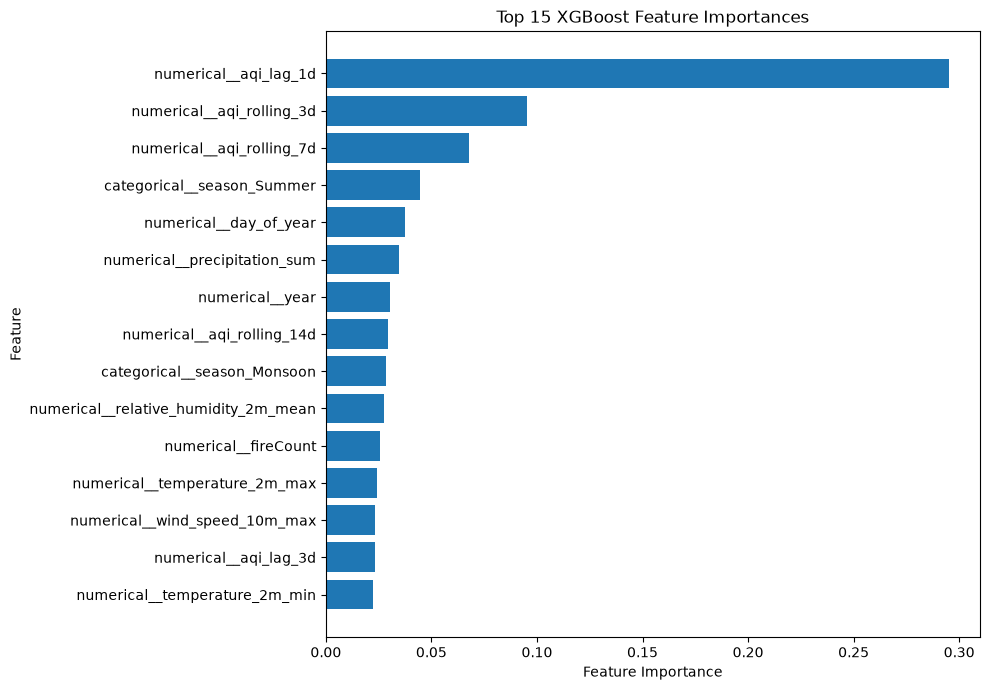

In [327]:
# ============================================================
# FINAL FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = (
    feature_importance_df
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

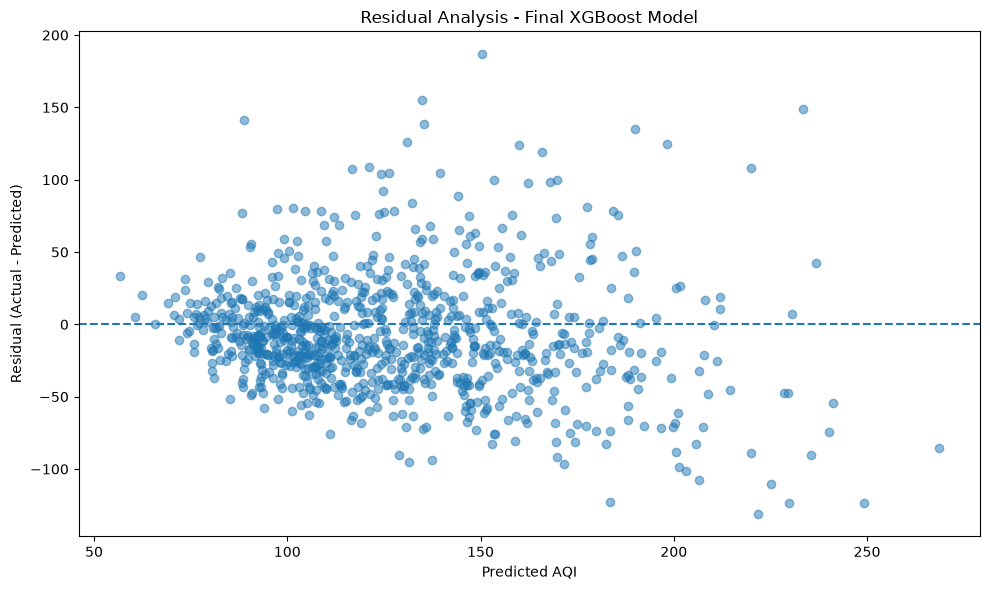

In [328]:
# ============================================================
# RESIDUAL ANALYSIS
# ============================================================

residual_df = pd.DataFrame({
    "actual": y_test_roll.values,
    "predicted": y_pred_xgb_roll
})

residual_df["residual"] = (
    residual_df["actual"] -
    residual_df["predicted"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    residual_df["predicted"],
    residual_df["residual"],
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted AQI")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis - Final XGBoost Model")

plt.tight_layout()
plt.show()

In [329]:
# ============================================================
# CHECK FINAL MODEL OBJECTS
# ============================================================

print("Model:", type(xgb_roll_model))
print("Preprocessor:", type(preprocessor_roll))

print("\nTraining samples:", len(y_train_roll))
print("Testing samples:", len(y_test_roll))

print("\nFinal Metrics:")
print(f"MAE  : {mae_xgb_roll:.4f}")
print(f"RMSE : {rmse_xgb_roll:.4f}")
print(f"R²   : {r2_xgb_roll:.4f}")

Model: <class 'xgboost.sklearn.XGBRegressor'>
Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>

Training samples: 3602
Testing samples: 898

Final Metrics:
MAE  : 30.6604
RMSE : 40.4623
R²   : 0.3191


In [330]:
# ============================================================
# SAVE FINAL AIRSHIELD MODEL
# ============================================================

import os
import joblib

# Create model directory
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)


# ------------------------------------------------------------
# 1. SAVE XGBOOST MODEL
# ------------------------------------------------------------

model_path = os.path.join(
    model_dir,
    "airshield_xgboost.pkl"
)

joblib.dump(
    xgb_roll_model,
    model_path
)


# ------------------------------------------------------------
# 2. SAVE PREPROCESSOR
# ------------------------------------------------------------

preprocessor_path = os.path.join(
    model_dir,
    "airshield_preprocessor.pkl"
)

joblib.dump(
    preprocessor_roll,
    preprocessor_path
)


# ------------------------------------------------------------
# 3. SAVE FEATURE CONFIGURATION
# ------------------------------------------------------------

feature_config = {
    "categorical_features": categorical_features_roll,
    "numerical_features": numerical_features_roll,
    "target": "aqi_value",
    "model": "XGBoost",
    "metrics": {
        "MAE": float(mae_xgb_roll),
        "RMSE": float(rmse_xgb_roll),
        "R2": float(r2_xgb_roll)
    }
}

config_path = os.path.join(
    model_dir,
    "airshield_feature_config.pkl"
)

joblib.dump(
    feature_config,
    config_path
)


# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

print("=" * 55)
print("FINAL MODEL SAVED")
print("=" * 55)

print("Model       :", model_path)
print("Preprocessor:", preprocessor_path)
print("Config      :", config_path)

print("\nFinal Metrics:")
print(f"MAE  : {mae_xgb_roll:.4f}")
print(f"RMSE : {rmse_xgb_roll:.4f}")
print(f"R²   : {r2_xgb_roll:.4f}")

FINAL MODEL SAVED
Model       : ../models\airshield_xgboost.pkl
Preprocessor: ../models\airshield_preprocessor.pkl
Config      : ../models\airshield_feature_config.pkl

Final Metrics:
MAE  : 30.6604
RMSE : 40.4623
R²   : 0.3191


In [331]:
# ============================================================
# TEST SAVED FINAL MODEL
# ============================================================

import joblib
import os

model_path = "../models/airshield_xgboost.pkl"
preprocessor_path = "../models/airshield_preprocessor.pkl"
config_path = "../models/airshield_feature_config.pkl"

loaded_model = joblib.load(model_path)
loaded_preprocessor = joblib.load(preprocessor_path)
loaded_config = joblib.load(config_path)

print("Model loaded:", type(loaded_model))
print("Preprocessor loaded:", type(loaded_preprocessor))
print("Config loaded:", type(loaded_config))

print("\nModel configuration:")
print(loaded_config)

Model loaded: <class 'xgboost.sklearn.XGBRegressor'>
Preprocessor loaded: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Config loaded: <class 'dict'>

Model configuration:
{'categorical_features': ['area', 'season'], 'numerical_features': ['fireCount', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'surface_pressure_mean', 'month', 'day_of_year', 'year', 'aqi_lag_1d', 'aqi_lag_3d', 'aqi_lag_7d', 'aqi_rolling_3d', 'aqi_rolling_7d', 'aqi_rolling_14d'], 'target': 'aqi_value', 'model': 'XGBoost', 'metrics': {'MAE': 30.660443384557098, 'RMSE': 40.46230456831987, 'R2': 0.31908430033192725}}


In [332]:
# ============================================================
# VERIFY SAVED MODEL ON ONE TEST SAMPLE
# ============================================================

# Take one row from the final test set
sample = test_roll.iloc[[0]].copy()

# Actual AQI
actual_aqi = sample["aqi_value"].iloc[0]

# Remove target and date
sample_X = sample.drop(
    columns=["aqi_value", "date"]
)

# Transform using SAVED preprocessor
sample_processed = loaded_preprocessor.transform(
    sample_X
)

# Prediction using SAVED model
saved_prediction = loaded_model.predict(
    sample_processed
)[0]

# Prediction using original in-memory model
original_prediction = xgb_roll_model.predict(
    preprocessor_roll.transform(
        sample_X
    )
)[0]

print("=" * 55)
print("SAVED MODEL VERIFICATION")
print("=" * 55)

print("Date:", sample["date"].iloc[0])
print("Area:", sample["area"].iloc[0])

print(f"\nActual AQI       : {actual_aqi:.2f}")
print(f"Original model   : {original_prediction:.2f}")
print(f"Saved model      : {saved_prediction:.2f}")

print(
    "\nDifference:",
    abs(original_prediction - saved_prediction)
)

SAVED MODEL VERIFICATION
Date: 2023-12-30 00:00:00
Area: Amritsar

Actual AQI       : 118.00
Original model   : 138.41
Saved model      : 138.41

Difference: 0.0


In [333]:
# Historical pseudo-future backtest

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


# 1. Load dataset
df = pd.read_csv("../data/processed/final_merged_dataset.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["area", "date"]).reset_index(drop=True)


# 2. Create ONLY past-AQI features
df["aqi_lag_1d"] = df.groupby("area")["aqi_value"].shift(1)
df["aqi_lag_3d"] = df.groupby("area")["aqi_value"].shift(3)
df["aqi_lag_7d"] = df.groupby("area")["aqi_value"].shift(7)

df["aqi_rolling_3d"] = (
    df.groupby("area")["aqi_value"]
      .shift(1)
      .rolling(3)
      .mean()
      .reset_index(level=0, drop=True)
)

df["aqi_rolling_7d"] = (
    df.groupby("area")["aqi_value"]
      .shift(1)
      .rolling(7)
      .mean()
      .reset_index(level=0, drop=True)
)


# 3. Time features
df["month"] = df["date"].dt.month
df["day_of_year"] = df["date"].dt.dayofyear
df["year"] = df["date"].dt.year


def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"


df["season"] = df["month"].apply(get_season)


# 4. Remove rows where past AQI history is unavailable
df = df.dropna(
    subset=[
        "aqi_lag_1d",
        "aqi_lag_3d",
        "aqi_lag_7d",
        "aqi_rolling_3d",
        "aqi_rolling_7d"
    ]
)


# 5. Historical forecasting split
# Train = before 2024
# Test  = 2024
train_df = df[df["date"] < "2024-01-01"].copy()
test_df = df[df["date"] >= "2024-01-01"].copy()


# 6. Features
categorical_features = ["area", "season"]

numerical_features = [
    "fireCount",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "month",
    "day_of_year",
    "year",
    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d",
    "aqi_rolling_3d",
    "aqi_rolling_7d"
]

features = categorical_features + numerical_features

X_train = train_df[features]
y_train = train_df["aqi_value"]

X_test = test_df[features]
y_test = test_df["aqi_value"]


# 7. Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


# 8. Train XGBoost
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_processed, y_train)


# 9. Predictions
pred = model.predict(X_test_processed)


# 10. Metrics
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Historical Forecast Backtest")
print("-----------------------------")
print("Train rows:", len(train_df))
print("Test rows :", len(test_df))
print()
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Historical Forecast Backtest
-----------------------------
Train rows: 3572
Test rows : 886

MAE : 30.95
RMSE: 41.46
R²  : 0.2873


In [334]:
# ============================================================
# NAIVE BASELINE: YESTERDAY'S AQI
# ============================================================

baseline_pred = test_df["aqi_lag_1d"].values
actual = test_df["aqi_value"].values

baseline_mae = mean_absolute_error(
    actual,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        actual,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    actual,
    baseline_pred
)

print("Naive Baseline: Yesterday's AQI")
print("--------------------------------")
print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R²  :", round(baseline_r2, 4))

print()
print("XGBoost:")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Naive Baseline: Yesterday's AQI
--------------------------------
MAE : 29.81
RMSE: 43.09
R²  : 0.2304

XGBoost:
MAE : 30.95
RMSE: 41.46
R²  : 0.2873


In [335]:
# ============================================================
# AREA-WISE MODEL vs NAIVE BASELINE
# ============================================================

results = []

for area in sorted(test_df["area"].unique()):

    mask = test_df["area"] == area

    actual_area = y_test[mask]
    pred_area = pred[mask]
    baseline_area = test_df.loc[
        mask, "aqi_lag_1d"
    ]

    model_mae = mean_absolute_error(
        actual_area,
        pred_area
    )

    model_rmse = np.sqrt(
        mean_squared_error(
            actual_area,
            pred_area
        )
    )

    baseline_mae = mean_absolute_error(
        actual_area,
        baseline_area
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            actual_area,
            baseline_area
        )
    )

    results.append({
        "Area": area,
        "Baseline MAE": round(baseline_mae, 2),
        "XGBoost MAE": round(model_mae, 2),
        "MAE Improvement": round(
            baseline_mae - model_mae,
            2
        ),
        "Baseline RMSE": round(baseline_rmse, 2),
        "XGBoost RMSE": round(model_rmse, 2),
        "RMSE Improvement": round(
            baseline_rmse - model_rmse,
            2
        )
    })


area_results = pd.DataFrame(results)

print("=" * 90)
print("AREA-WISE FORECAST VALIDATION")
print("=" * 90)

print(
    area_results.to_string(
        index=False
    )
)

print("=" * 90)

print(
    "\nAreas where XGBoost improves MAE:"
)

print(
    area_results[
        area_results["MAE Improvement"] > 0
    ][["Area", "MAE Improvement"]]
    .to_string(index=False)
)

print(
    "\nAreas where XGBoost improves RMSE:"
)

print(
    area_results[
        area_results["RMSE Improvement"] > 0
    ][["Area", "RMSE Improvement"]]
    .to_string(index=False)
)

AREA-WISE FORECAST VALIDATION
     Area  Baseline MAE  XGBoost MAE  MAE Improvement  Baseline RMSE  XGBoost RMSE  RMSE Improvement
 Amritsar         18.22        22.28            -4.05          25.77         27.78             -2.01
 Bathinda         33.92        35.23            -1.31          46.14         45.01              1.13
Jalandhar         24.61        25.94            -1.33          33.20         34.63             -1.43
 Ludhiana         34.80        36.24            -1.43          49.70         46.44              3.26
  Patiala         23.10        21.79             1.31          32.31         28.88              3.43
 Rupnagar         44.23        44.37            -0.14          61.16         57.85              3.31

Areas where XGBoost improves MAE:
   Area  MAE Improvement
Patiala             1.31

Areas where XGBoost improves RMSE:
    Area  RMSE Improvement
Bathinda              1.13
Ludhiana              3.26
 Patiala              3.43
Rupnagar              3.31


In [336]:
# ============================================================
# EXACT SAVED AIRSHIELD MODEL - HISTORICAL FORECAST BACKTEST
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(
    "../data/processed/final_merged_dataset.csv"
)

df["date"] = pd.to_datetime(
    df["date"]
)

df = (
    df
    .sort_values(
        ["area", "date"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 2. CREATE HISTORICAL AQI FEATURES
# ============================================================

grouped_aqi = (
    df.groupby("area")["aqi_value"]
)


# Exact calendar-day lags
df["aqi_lag_1d"] = grouped_aqi.shift(1)
df["aqi_lag_3d"] = grouped_aqi.shift(3)
df["aqi_lag_7d"] = grouped_aqi.shift(7)


# Rolling features use ONLY previous observations
df["aqi_rolling_3d"] = (
    grouped_aqi
    .shift(1)
    .groupby(df["area"])
    .rolling(3)
    .mean()
    .reset_index(
        level=0,
        drop=True
    )
)

df["aqi_rolling_7d"] = (
    grouped_aqi
    .shift(1)
    .groupby(df["area"])
    .rolling(7)
    .mean()
    .reset_index(
        level=0,
        drop=True
    )
)

df["aqi_rolling_14d"] = (
    grouped_aqi
    .shift(1)
    .groupby(df["area"])
    .rolling(14)
    .mean()
    .reset_index(
        level=0,
        drop=True
    )
)


# ============================================================
# 3. DATE FEATURES
# ============================================================

df["month"] = (
    df["date"].dt.month
)

df["day_of_year"] = (
    df["date"].dt.dayofyear
)

df["year"] = (
    df["date"].dt.year
)


def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Summer"

    elif month in [6, 7, 8, 9]:
        return "Monsoon"

    else:
        return "Post-Monsoon"


df["season"] = (
    df["month"]
    .apply(get_season)
)


# ============================================================
# 4. SAME FEATURES AS SAVED MODEL
# ============================================================

categorical_features = [
    "area",
    "season"
]

numerical_features = [
    "fireCount",

    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",

    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",

    "month",
    "day_of_year",
    "year",

    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d",

    "aqi_rolling_3d",
    "aqi_rolling_7d",
    "aqi_rolling_14d"
]

features = (
    categorical_features
    + numerical_features
)


# ============================================================
# 5. REMOVE ROWS WITHOUT COMPLETE HISTORY
# ============================================================

df_testable = df.dropna(
    subset=[
        "aqi_lag_1d",
        "aqi_lag_3d",
        "aqi_lag_7d",
        "aqi_rolling_3d",
        "aqi_rolling_7d",
        "aqi_rolling_14d"
    ]
).copy()


# ============================================================
# 6. CHRONOLOGICAL TEST PERIOD
# ============================================================

test_df_exact = df_testable[
    df_testable["date"] >= "2024-01-01"
].copy()


X_test_exact = (
    test_df_exact[features]
)

y_test_exact = (
    test_df_exact["aqi_value"]
)


# ============================================================
# 7. LOAD SAVED MODEL + PREPROCESSOR
# ============================================================

MODEL_PATH = "../models/airshield_xgboost.pkl"

PREPROCESSOR_PATH = (
    "../models/airshield_preprocessor.pkl"
)


saved_model = joblib.load(
    MODEL_PATH
)

saved_preprocessor = joblib.load(
    PREPROCESSOR_PATH
)


print("=" * 70)
print("EXACT SAVED MODEL BACKTEST")
print("=" * 70)

print(
    "Model:",
    type(saved_model).__name__
)

print(
    "Test rows:",
    len(test_df_exact)
)


# ============================================================
# 8. TRANSFORM USING SAVED PREPROCESSOR
# ============================================================

X_test_processed_exact = (
    saved_preprocessor.transform(
        X_test_exact
    )
)


# ============================================================
# 9. PREDICT USING SAVED MODEL
# ============================================================

saved_predictions = (
    saved_model.predict(
        X_test_processed_exact
    )
)


# ============================================================
# 10. METRICS
# ============================================================

saved_mae = mean_absolute_error(
    y_test_exact,
    saved_predictions
)

saved_rmse = np.sqrt(
    mean_squared_error(
        y_test_exact,
        saved_predictions
    )
)

saved_r2 = r2_score(
    y_test_exact,
    saved_predictions
)


print()
print("Saved Model Performance")
print("-----------------------")

print(
    "MAE :",
    round(saved_mae, 2)
)

print(
    "RMSE:",
    round(saved_rmse, 2)
)

print(
    "R²  :",
    round(saved_r2, 4)
)


# ============================================================
# 11. NAIVE BASELINE
# ============================================================

baseline_predictions = (
    test_df_exact["aqi_lag_1d"]
)

baseline_mae = mean_absolute_error(
    y_test_exact,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test_exact,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test_exact,
    baseline_predictions
)


print()
print("Naive Baseline")
print("--------------")

print(
    "MAE :",
    round(baseline_mae, 2)
)

print(
    "RMSE:",
    round(baseline_rmse, 2)
)

print(
    "R²  :",
    round(baseline_r2, 4)
)


# ============================================================
# 12. COMPARISON
# ============================================================

print()
print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)

print(
    f"MAE improvement : "
    f"{baseline_mae - saved_mae:.2f}"
)

print(
    f"RMSE improvement: "
    f"{baseline_rmse - saved_rmse:.2f}"
)

print(
    f"R² improvement  : "
    f"{saved_r2 - baseline_r2:.4f}"
)

print("=" * 70)

EXACT SAVED MODEL BACKTEST
Model: XGBRegressor
Test rows: 886

Saved Model Performance
-----------------------
MAE : 30.09
RMSE: 40.12
R²  : 0.3326

Naive Baseline
--------------
MAE : 29.81
RMSE: 43.09
R²  : 0.2304

FINAL COMPARISON
MAE improvement : -0.28
RMSE improvement: 2.96
R² improvement  : 0.1022


In [337]:
# ============================================================
# AIRSHIELD ERROR ANALYSIS
# ============================================================

analysis_df = test_df_exact[
    [
        "date",
        "area",
        "aqi_value",
        "aqi_lag_1d",
        "fireCount"
    ]
].copy()

analysis_df["xgb_prediction"] = saved_predictions

analysis_df["xgb_error"] = (
    analysis_df["aqi_value"]
    - analysis_df["xgb_prediction"]
)

analysis_df["xgb_abs_error"] = (
    analysis_df["xgb_error"]
    .abs()
)

analysis_df["baseline_prediction"] = (
    analysis_df["aqi_lag_1d"]
)

analysis_df["baseline_abs_error"] = (
    analysis_df["aqi_value"]
    - analysis_df["baseline_prediction"]
).abs()

analysis_df["xgb_better"] = (
    analysis_df["xgb_abs_error"]
    < analysis_df["baseline_abs_error"]
)

analysis_df["month"] = (
    analysis_df["date"].dt.month
)


# ============================================================
# 1. OVERALL ERROR COMPARISON
# ============================================================

print("=" * 75)
print("OVERALL ERROR ANALYSIS")
print("=" * 75)

print(
    "XGBoost mean absolute error :",
    round(
        analysis_df["xgb_abs_error"].mean(),
        2
    )
)

print(
    "Baseline mean absolute error:",
    round(
        analysis_df["baseline_abs_error"].mean(),
        2
    )
)

print()

print(
    "XGBoost better on:",
    round(
        analysis_df["xgb_better"].mean() * 100,
        2
    ),
    "% of test days"
)


# ============================================================
# 2. AQI RANGE ANALYSIS
# ============================================================

def aqi_range(aqi):

    if aqi <= 50:
        return "0-50"

    elif aqi <= 100:
        return "51-100"

    elif aqi <= 200:
        return "101-200"

    elif aqi <= 300:
        return "201-300"

    else:
        return "300+"


analysis_df["aqi_range"] = (
    analysis_df["aqi_value"]
    .apply(aqi_range)
)


range_results = (
    analysis_df
    .groupby("aqi_range")
    .agg(
        days=("aqi_value", "count"),
        baseline_mae=(
            "baseline_abs_error",
            "mean"
        ),
        xgb_mae=(
            "xgb_abs_error",
            "mean"
        ),
        xgb_better_pct=(
            "xgb_better",
            "mean"
        )
    )
    .reset_index()
)

range_results["xgb_better_pct"] *= 100

range_results["improvement"] = (
    range_results["baseline_mae"]
    - range_results["xgb_mae"]
)

print()
print("=" * 75)
print("ERROR BY ACTUAL AQI RANGE")
print("=" * 75)

print(
    range_results.round(2).to_string(
        index=False
    )
)


# ============================================================
# 3. MONTH-WISE ANALYSIS
# ============================================================

month_results = (
    analysis_df
    .groupby("month")
    .agg(
        days=("aqi_value", "count"),
        avg_aqi=("aqi_value", "mean"),
        baseline_mae=(
            "baseline_abs_error",
            "mean"
        ),
        xgb_mae=(
            "xgb_abs_error",
            "mean"
        ),
        avg_fire=("fireCount", "mean")
    )
    .reset_index()
)

month_results["improvement"] = (
    month_results["baseline_mae"]
    - month_results["xgb_mae"]
)

print()
print("=" * 75)
print("MONTH-WISE ERROR ANALYSIS")
print("=" * 75)

print(
    month_results.round(2).to_string(
        index=False
    )
)


# ============================================================
# 4. AREA-WISE ERROR ANALYSIS
# ============================================================

area_error = (
    analysis_df
    .groupby("area")
    .agg(
        days=("aqi_value", "count"),
        avg_aqi=("aqi_value", "mean"),
        baseline_mae=(
            "baseline_abs_error",
            "mean"
        ),
        xgb_mae=(
            "xgb_abs_error",
            "mean"
        ),
        avg_fire=("fireCount", "mean")
    )
    .reset_index()
)

area_error["improvement"] = (
    area_error["baseline_mae"]
    - area_error["xgb_mae"]
)

print()
print("=" * 75)
print("AREA-WISE ERROR ANALYSIS")
print("=" * 75)

print(
    area_error.round(2).to_string(
        index=False
    )
)


# ============================================================
# 5. WORST XGBOOST PREDICTIONS
# ============================================================

worst_predictions = (
    analysis_df
    .sort_values(
        "xgb_abs_error",
        ascending=False
    )
    .head(15)
)

print()
print("=" * 75)
print("15 WORST XGBOOST PREDICTIONS")
print("=" * 75)

print(
    worst_predictions[
        [
            "date",
            "area",
            "aqi_value",
            "xgb_prediction",
            "aqi_lag_1d",
            "fireCount",
            "xgb_abs_error"
        ]
    ]
    .round(2)
    .to_string(index=False)
)


# ============================================================
# 6. FIRE DAYS
# ============================================================

fire_days = analysis_df[
    analysis_df["fireCount"] > 0
]

print()
print("=" * 75)
print("FIRE-DAY ANALYSIS")
print("=" * 75)

print(
    "Total fire days:",
    len(fire_days)
)

if len(fire_days) > 0:

    print(
        "Fire-day XGBoost MAE:",
        round(
            fire_days["xgb_abs_error"].mean(),
            2
        )
    )

    print(
        "Fire-day Baseline MAE:",
        round(
            fire_days["baseline_abs_error"].mean(),
            2
        )
    )

else:

    print(
        "No non-zero fire days in test period."
    )

print("=" * 75)

OVERALL ERROR ANALYSIS
XGBoost mean absolute error : 30.09
Baseline mean absolute error: 29.81

XGBoost better on: 47.74 % of test days

ERROR BY ACTUAL AQI RANGE
aqi_range  days  baseline_mae  xgb_mae  xgb_better_pct  improvement
     0-50    20         39.20    55.80           25.00       -16.60
  101-200   451         31.12    24.71           59.20         6.42
  201-300    58         59.38    68.48           46.55        -9.10
     300+     5        128.00   143.76           60.00       -15.76
   51-100   352         21.32    27.58           34.38        -6.27

MONTH-WISE ERROR ANALYSIS
 month  days  avg_aqi  baseline_mae  xgb_mae  avg_fire  improvement
     1   178   147.93         43.28    40.18      0.00         3.11
     2   163   108.59         29.10    29.99      0.00        -0.89
     3   172   104.90         20.85    24.77      0.00        -3.92
     4   168    89.97         22.07    23.50      0.29        -1.44
     5   177   134.72         30.86    29.90     19.42        

C:\Users\vaibh\AppData\Local\Temp\ipykernel_25100\983705671.py:260: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


In [338]:
# ============================================================
# SAVED MODEL FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import numpy as np


# Get transformed feature names
feature_names = (
    saved_preprocessor
    .get_feature_names_out()
)

importance = (
    saved_model.feature_importances_
)


importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})


importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 75)
print("SAVED MODEL FEATURE IMPORTANCE")
print("=" * 75)

print(
    importance_df
    .head(25)
    .round(4)
    .to_string(index=False)
)


print()
print("=" * 75)
print("TOP 10 FEATURES")
print("=" * 75)

print(
    importance_df
    .head(10)
    .round(4)
    .to_string(index=False)
)

SAVED MODEL FEATURE IMPORTANCE
                             feature  importance
               numerical__aqi_lag_1d      0.2951
           numerical__aqi_rolling_3d      0.0953
           numerical__aqi_rolling_7d      0.0676
          categorical__season_Summer      0.0444
              numerical__day_of_year      0.0375
        numerical__precipitation_sum      0.0348
                     numerical__year      0.0303
          numerical__aqi_rolling_14d      0.0294
         categorical__season_Monsoon      0.0284
numerical__relative_humidity_2m_mean      0.0277
                numerical__fireCount      0.0255
       numerical__temperature_2m_max      0.0240
       numerical__wind_speed_10m_max      0.0233
               numerical__aqi_lag_3d      0.0231
       numerical__temperature_2m_min      0.0225
          categorical__area_Bathinda      0.0221
    numerical__surface_pressure_mean      0.0211
               numerical__aqi_lag_7d      0.0208
                    numerical__month  

In [339]:
print(train_df.columns.tolist())

['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit', 'note', 'fireCount', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'surface_pressure_mean', 'aqi_lag_1d', 'aqi_lag_3d', 'aqi_lag_7d', 'aqi_rolling_3d', 'aqi_rolling_7d', 'month', 'day_of_year', 'year', 'season']


In [340]:
# ============================================================
# AIRSHIELD ABLATION TEST - FIXED
# Uses ONLY features actually present in train_df
# ============================================================

import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# FEATURE GROUPS
# ============================================================

AQI_FEATURES = [
    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d",
    "aqi_rolling_3d",
    "aqi_rolling_7d"
]

WEATHER_FEATURES = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean"
]

FIRE_FEATURES = [
    "fireCount"
]

TIME_NUMERICAL_FEATURES = [
    "month",
    "day_of_year",
    "year"
]

TIME_CATEGORICAL_FEATURES = [
    "season"
]

LOCATION_FEATURES = [
    "area"
]


# ============================================================
# EVALUATION FUNCTION
# ============================================================

def run_ablation(name, feature_groups):

    features = []

    for group in feature_groups:
        features.extend(group)

    X_train = train_df[features].copy()
    X_test = test_df_exact[features].copy()

    y_train = train_df["aqi_value"]
    y_test = test_df_exact["aqi_value"]


    # --------------------------------------------------------
    # Identify categorical / numerical columns
    # --------------------------------------------------------

    categorical = [
        col
        for col in features
        if col in ["area", "season"]
    ]

    numerical = [
        col
        for col in features
        if col not in categorical
    ]


    # --------------------------------------------------------
    # Preprocessor
    # --------------------------------------------------------

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical
            ),
            (
                "num",
                "passthrough",
                numerical
            )
        ]
    )


    # --------------------------------------------------------
    # Transform
    # --------------------------------------------------------

    X_train_processed = (
        preprocessor.fit_transform(X_train)
    )

    X_test_processed = (
        preprocessor.transform(X_test)
    )


    # --------------------------------------------------------
    # Same model configuration
    # --------------------------------------------------------

    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train_processed,
        y_train
    )


    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    predictions = model.predict(
        X_test_processed
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )


    return {
        "Model": name,
        "Features": len(features),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# ============================================================
# RUN ABLATION EXPERIMENTS
# ============================================================

results = []


# ------------------------------------------------------------
# 1. Past AQI only
# ------------------------------------------------------------

results.append(
    run_ablation(
        "Past AQI only",
        [
            AQI_FEATURES
        ]
    )
)


# ------------------------------------------------------------
# 2. Past AQI + Weather
# ------------------------------------------------------------

results.append(
    run_ablation(
        "Past AQI + Weather",
        [
            AQI_FEATURES,
            WEATHER_FEATURES
        ]
    )
)


# ------------------------------------------------------------
# 3. Past AQI + Fire
# ------------------------------------------------------------

results.append(
    run_ablation(
        "Past AQI + Fire",
        [
            AQI_FEATURES,
            FIRE_FEATURES
        ]
    )
)


# ------------------------------------------------------------
# 4. Past AQI + Weather + Fire
# ------------------------------------------------------------

results.append(
    run_ablation(
        "Past AQI + Weather + Fire",
        [
            AQI_FEATURES,
            WEATHER_FEATURES,
            FIRE_FEATURES
        ]
    )
)


# ------------------------------------------------------------
# 5. Full feature model
# ------------------------------------------------------------

results.append(
    run_ablation(
        "Full model",
        [
            AQI_FEATURES,
            WEATHER_FEATURES,
            FIRE_FEATURES,
            TIME_NUMERICAL_FEATURES,
            TIME_CATEGORICAL_FEATURES,
            LOCATION_FEATURES
        ]
    )
)


# ============================================================
# RESULTS
# ============================================================

ablation_results = pd.DataFrame(
    results
)

print("=" * 80)
print("AIRSHIELD ABLATION TEST")
print("=" * 80)

print(
    ablation_results
    .round(3)
    .to_string(index=False)
)

print("=" * 80)

AIRSHIELD ABLATION TEST
                    Model  Features    MAE   RMSE    R2
            Past AQI only         5 28.101 39.574 0.351
       Past AQI + Weather        12 30.123 40.579 0.317
          Past AQI + Fire         6 28.080 39.472 0.354
Past AQI + Weather + Fire        13 29.998 40.695 0.313
               Full model        18 29.584 39.788 0.344


In [341]:
# ============================================================
# AIRSHIELD AQI SPIKE ANALYSIS
# ============================================================

spike_df = analysis_df.copy()

# AQI change from previous day
spike_df["aqi_change"] = (
    spike_df["aqi_value"]
    - spike_df["aqi_lag_1d"]
)

# Absolute change
spike_df["abs_aqi_change"] = (
    spike_df["aqi_change"].abs()
)

# Define spike
spike_df["is_spike"] = (
    spike_df["aqi_change"] >= 50
)


# ============================================================
# 1. BASIC SPIKE STATISTICS
# ============================================================

print("=" * 75)
print("AQI SPIKE ANALYSIS")
print("=" * 75)

print(
    "Total test days:",
    len(spike_df)
)

print(
    "AQI spike days (increase >= 50):",
    spike_df["is_spike"].sum()
)

print(
    "Spike percentage:",
    round(
        spike_df["is_spike"].mean() * 100,
        2
    ),
    "%"
)


# ============================================================
# 2. SPIKE-DAY PERFORMANCE
# ============================================================

spikes = spike_df[
    spike_df["is_spike"]
].copy()

non_spikes = spike_df[
    ~spike_df["is_spike"]
].copy()


print()
print("=" * 75)
print("SPIKE-DAY PERFORMANCE")
print("=" * 75)

if len(spikes) > 0:

    print(
        "Spike days:",
        len(spikes)
    )

    print(
        "Baseline MAE:",
        round(
            spikes["baseline_abs_error"].mean(),
            2
        )
    )

    print(
        "XGBoost MAE:",
        round(
            spikes["xgb_abs_error"].mean(),
            2
        )
    )

    print(
        "XGBoost improvement:",
        round(
            spikes["baseline_abs_error"].mean()
            - spikes["xgb_abs_error"].mean(),
            2
        )
    )

else:

    print("No AQI spike days found.")


# ============================================================
# 3. NON-SPIKE PERFORMANCE
# ============================================================

print()
print("=" * 75)
print("NON-SPIKE PERFORMANCE")
print("=" * 75)

if len(non_spikes) > 0:

    print(
        "Non-spike days:",
        len(non_spikes)
    )

    print(
        "Baseline MAE:",
        round(
            non_spikes["baseline_abs_error"].mean(),
            2
        )
    )

    print(
        "XGBoost MAE:",
        round(
            non_spikes["xgb_abs_error"].mean(),
            2
        )
    )


# ============================================================
# 4. WHAT HAPPENS ON SPIKE DAYS?
# ============================================================

print()
print("=" * 75)
print("SPIKE-DAY DETAILS")
print("=" * 75)

if len(spikes) > 0:

    print(
        spikes[
            [
                "date",
                "area",
                "aqi_value",
                "aqi_lag_1d",
                "aqi_change",
                "xgb_prediction",
                "fireCount",
                "xgb_abs_error",
                "baseline_abs_error"
            ]
        ]
        .sort_values(
            "aqi_change",
            ascending=False
        )
        .round(2)
        .to_string(index=False)
    )


# ============================================================
# 5. SPIKES BY AREA
# ============================================================

print()
print("=" * 75)
print("SPIKES BY AREA")
print("=" * 75)

if len(spikes) > 0:

    spike_area = (
        spikes
        .groupby("area")
        .agg(
            spike_days=("is_spike", "count"),
            avg_aqi_change=("aqi_change", "mean"),
            baseline_mae=(
                "baseline_abs_error",
                "mean"
            ),
            xgb_mae=(
                "xgb_abs_error",
                "mean"
            ),
            avg_fire=("fireCount", "mean")
        )
        .reset_index()
    )

    spike_area["improvement"] = (
        spike_area["baseline_mae"]
        - spike_area["xgb_mae"]
    )

    print(
        spike_area
        .round(2)
        .to_string(index=False)
    )


# ============================================================
# 6. SPIKES BY MONTH
# ============================================================

print()
print("=" * 75)
print("SPIKES BY MONTH")
print("=" * 75)

if len(spikes) > 0:

    spike_month = (
        spikes
        .groupby("month")
        .agg(
            spike_days=("is_spike", "count"),
            avg_aqi_change=("aqi_change", "mean"),
            baseline_mae=(
                "baseline_abs_error",
                "mean"
            ),
            xgb_mae=(
                "xgb_abs_error",
                "mean"
            ),
            avg_fire=("fireCount", "mean")
        )
        .reset_index()
    )

    spike_month["improvement"] = (
        spike_month["baseline_mae"]
        - spike_month["xgb_mae"]
    )

    print(
        spike_month
        .round(2)
        .to_string(index=False)
    )


# ============================================================
# 7. FIRE ON SPIKE DAYS
# ============================================================

print()
print("=" * 75)
print("FIRE SIGNAL ON SPIKE DAYS")
print("=" * 75)

if len(spikes) > 0:

    fire_spikes = spikes[
        spikes["fireCount"] > 0
    ]

    no_fire_spikes = spikes[
        spikes["fireCount"] == 0
    ]

    print(
        "Spike days with fire:",
        len(fire_spikes)
    )

    print(
        "Spike days without fire:",
        len(no_fire_spikes)
    )

    if len(fire_spikes) > 0:

        print(
            "Average fireCount on spike days:",
            round(
                fire_spikes["fireCount"].mean(),
                2
            )
        )

    if len(no_fire_spikes) > 0:

        print(
            "Average fireCount on non-fire spike days:",
            round(
                no_fire_spikes["fireCount"].mean(),
                2
            )
        )


print()
print("=" * 75)
print("SPIKE ANALYSIS COMPLETE")
print("=" * 75)

AQI SPIKE ANALYSIS
Total test days: 886
AQI spike days (increase >= 50): 81
Spike percentage: 9.14 %

SPIKE-DAY PERFORMANCE
Spike days: 81
Baseline MAE: 83.91
XGBoost MAE: 61.18
XGBoost improvement: 22.74

NON-SPIKE PERFORMANCE
Non-spike days: 805
Baseline MAE: 24.36
XGBoost MAE: 26.96

SPIKE-DAY DETAILS
      date      area  aqi_value  aqi_lag_1d  aqi_change  xgb_prediction  fireCount  xgb_abs_error  baseline_abs_error
2024-06-04  Bathinda      337.0       130.0       207.0      136.190002        0.0         200.81               207.0
2024-01-13  Rupnagar      274.0        97.0       177.0      135.300003        0.0         138.70               177.0
2024-01-17  Ludhiana      284.0       131.0       153.0      159.889999        0.0         124.11               153.0
2024-05-11  Rupnagar      290.0       142.0       148.0      135.990005        0.0         154.01               148.0
2024-01-13  Ludhiana      328.0       182.0       146.0      219.949997        0.0         108.05       

C:\Users\vaibh\AppData\Local\Temp\ipykernel_25100\2817969445.py:169: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


In [342]:
# ============================================================
# AIRSHIELD: AQI CHANGE PREDICTION
# ============================================================

import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. COPY DATA
# ============================================================

train_change = train_df.copy()
test_change = test_df_exact.copy()


# ============================================================
# 2. TARGET = AQI CHANGE
# ============================================================

train_change["aqi_change_target"] = (
    train_change["aqi_value"]
    - train_change["aqi_lag_1d"]
)

test_change["aqi_change_target"] = (
    test_change["aqi_value"]
    - test_change["aqi_lag_1d"]
)


# Remove rows where yesterday's AQI is unavailable
train_change = train_change.dropna(
    subset=["aqi_change_target"]
)

test_change = test_change.dropna(
    subset=["aqi_change_target"]
)


# ============================================================
# 3. FEATURES
# ============================================================

FEATURES = [
    "area",
    "season",

    "fireCount",

    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",

    "month",
    "day_of_year",
    "year",

    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d",
    "aqi_rolling_3d",
    "aqi_rolling_7d"
]


X_train = train_change[FEATURES]
X_test = test_change[FEATURES]

y_train = train_change["aqi_change_target"]
y_test = test_change["aqi_change_target"]


# ============================================================
# 4. PREPROCESSOR
# ============================================================

categorical_features = [
    "area",
    "season"
]

numerical_features = [
    col
    for col in FEATURES
    if col not in categorical_features
]


preprocessor_change = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)


X_train_processed = (
    preprocessor_change
    .fit_transform(X_train)
)

X_test_processed = (
    preprocessor_change
    .transform(X_test)
)


# ============================================================
# 5. TRAIN CHANGE MODEL
# ============================================================

change_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)


change_model.fit(
    X_train_processed,
    y_train
)


# ============================================================
# 6. PREDICT AQI CHANGE
# ============================================================

predicted_change = change_model.predict(
    X_test_processed
)


# ============================================================
# 7. CONVERT CHANGE → AQI
# ============================================================

predicted_aqi = (
    test_change["aqi_lag_1d"].values
    + predicted_change
)

actual_aqi = (
    test_change["aqi_value"].values
)


# ============================================================
# 8. EVALUATE AQI PREDICTION
# ============================================================

mae = mean_absolute_error(
    actual_aqi,
    predicted_aqi
)

rmse = np.sqrt(
    mean_squared_error(
        actual_aqi,
        predicted_aqi
    )
)

r2 = r2_score(
    actual_aqi,
    predicted_aqi
)


print("=" * 75)
print("AQI CHANGE PREDICTION MODEL")
print("=" * 75)

print(
    "Test rows:",
    len(test_change)
)

print()
print("Change Model → AQI Performance")
print("-------------------------------")

print(
    f"MAE : {mae:.2f}"
)

print(
    f"RMSE: {rmse:.2f}"
)

print(
    f"R²  : {r2:.4f}"
)


# ============================================================
# 9. COMPARE WITH NAIVE BASELINE
# ============================================================

baseline_aqi = (
    test_change["aqi_lag_1d"].values
)

baseline_mae = mean_absolute_error(
    actual_aqi,
    baseline_aqi
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        actual_aqi,
        baseline_aqi
    )
)

baseline_r2 = r2_score(
    actual_aqi,
    baseline_aqi
)


print()
print("Naive Yesterday Baseline")
print("-------------------------")

print(
    f"MAE : {baseline_mae:.2f}"
)

print(
    f"RMSE: {baseline_rmse:.2f}"
)

print(
    f"R²  : {baseline_r2:.4f}"
)


# ============================================================
# 10. IMPROVEMENT
# ============================================================

print()
print("Improvement")
print("-----------")

print(
    f"MAE improvement : "
    f"{baseline_mae - mae:.2f}"
)

print(
    f"RMSE improvement: "
    f"{baseline_rmse - rmse:.2f}"
)

print(
    f"R² improvement  : "
    f"{r2 - baseline_r2:.4f}"
)

print("=" * 75)

AQI CHANGE PREDICTION MODEL
Test rows: 886

Change Model → AQI Performance
-------------------------------
MAE : 29.74
RMSE: 40.20
R²  : 0.3299

Naive Yesterday Baseline
-------------------------
MAE : 29.81
RMSE: 43.09
R²  : 0.2304

Improvement
-----------
MAE improvement : 0.06
RMSE improvement: 2.88
R² improvement  : 0.0995


In [343]:
# ============================================================
# CHANGE MODEL — SPIKE DAY ANALYSIS
# ============================================================

change_analysis = test_change.copy()

# Change-model AQI prediction
change_analysis["change_prediction"] = predicted_aqi

# Errors
change_analysis["change_abs_error"] = (
    change_analysis["aqi_value"]
    - change_analysis["change_prediction"]
).abs()

change_analysis["baseline_prediction"] = (
    change_analysis["aqi_lag_1d"]
)

change_analysis["baseline_abs_error"] = (
    change_analysis["aqi_value"]
    - change_analysis["baseline_prediction"]
).abs()

# Actual AQI change
change_analysis["actual_change"] = (
    change_analysis["aqi_value"]
    - change_analysis["aqi_lag_1d"]
)

# Spike = AQI increased by at least 50
change_analysis["is_spike"] = (
    change_analysis["actual_change"] >= 50
)


# ============================================================
# SPIKE VS NON-SPIKE
# ============================================================

spikes = change_analysis[
    change_analysis["is_spike"]
]

non_spikes = change_analysis[
    ~change_analysis["is_spike"]
]


print("=" * 75)
print("CHANGE MODEL — SPIKE DAY ANALYSIS")
print("=" * 75)

print()
print("Total test days :", len(change_analysis))
print("Spike days      :", len(spikes))
print(
    "Spike percentage:",
    round(len(spikes) / len(change_analysis) * 100, 2),
    "%"
)


# ============================================================
# SPIKE PERFORMANCE
# ============================================================

print()
print("SPIKE DAYS")
print("-" * 75)

print(
    "Baseline MAE:",
    round(
        spikes["baseline_abs_error"].mean(),
        2
    )
)

print(
    "Change Model MAE:",
    round(
        spikes["change_abs_error"].mean(),
        2
    )
)

print(
    "Improvement:",
    round(
        spikes["baseline_abs_error"].mean()
        - spikes["change_abs_error"].mean(),
        2
    )
)


# ============================================================
# NON-SPIKE PERFORMANCE
# ============================================================

print()
print("NON-SPIKE DAYS")
print("-" * 75)

print(
    "Baseline MAE:",
    round(
        non_spikes["baseline_abs_error"].mean(),
        2
    )
)

print(
    "Change Model MAE:",
    round(
        non_spikes["change_abs_error"].mean(),
        2
    )
)

print(
    "Improvement:",
    round(
        non_spikes["baseline_abs_error"].mean()
        - non_spikes["change_abs_error"].mean(),
        2
    )
)


# ============================================================
# WORST SPIKES
# ============================================================

print()
print("=" * 75)
print("WORST AQI SPIKES")
print("=" * 75)

if len(spikes) > 0:

    worst_spikes = (
        spikes[
            [
                "date",
                "area",
                "aqi_lag_1d",
                "aqi_value",
                "actual_change",
                "change_prediction",
                "change_abs_error",
                "fireCount"
            ]
        ]
        .sort_values(
            "actual_change",
            ascending=False
        )
        .head(15)
    )

    print(
        worst_spikes
        .round(2)
        .to_string(index=False)
    )


# ============================================================
# SPIKE PERFORMANCE BY AREA
# ============================================================

print()
print("=" * 75)
print("SPIKE PERFORMANCE BY AREA")
print("=" * 75)

if len(spikes) > 0:

    area_result = (
        spikes
        .groupby("area")
        .agg(
            spike_days=("is_spike", "count"),
            baseline_mae=(
                "baseline_abs_error",
                "mean"
            ),
            change_model_mae=(
                "change_abs_error",
                "mean"
            ),
            avg_change=(
                "actual_change",
                "mean"
            ),
            avg_fire=(
                "fireCount",
                "mean"
            )
        )
        .reset_index()
    )

    area_result["improvement"] = (
        area_result["baseline_mae"]
        - area_result["change_model_mae"]
    )

    print(
        area_result
        .round(2)
        .to_string(index=False)
    )


print()
print("=" * 75)
print("ANALYSIS COMPLETE")
print("=" * 75)

CHANGE MODEL — SPIKE DAY ANALYSIS

Total test days : 886
Spike days      : 81
Spike percentage: 9.14 %

SPIKE DAYS
---------------------------------------------------------------------------
Baseline MAE: 83.91
Change Model MAE: 64.58
Improvement: 19.34

NON-SPIKE DAYS
---------------------------------------------------------------------------
Baseline MAE: 24.36
Change Model MAE: 26.24
Improvement: -1.88

WORST AQI SPIKES
      date     area  aqi_lag_1d  aqi_value  actual_change  change_prediction  change_abs_error  fireCount
2024-06-04 Bathinda       130.0      337.0          207.0             152.40            184.60        0.0
2024-01-13 Rupnagar        97.0      274.0          177.0             119.81            154.19        0.0
2024-01-17 Ludhiana       131.0      284.0          153.0             177.02            106.98        0.0
2024-05-11 Rupnagar       142.0      290.0          148.0             138.64            151.36        0.0
2024-01-13 Ludhiana       182.0      328.0 

C:\Users\vaibh\AppData\Local\Temp\ipykernel_25100\2493368356.py:165: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


In [344]:
# ============================================================
# AIRSHIELD FEATURE AVAILABILITY AUDIT
# ============================================================

feature_availability = pd.DataFrame([
    ["aqi_lag_1d", "Historical AQI", "YES", "Known before target date"],
    ["aqi_lag_3d", "Historical AQI", "YES", "Known before target date"],
    ["aqi_lag_7d", "Historical AQI", "YES", "Known before target date"],
    ["aqi_rolling_3d", "Historical AQI", "YES", "Uses only past AQI"],
    ["aqi_rolling_7d", "Historical AQI", "YES", "Uses only past AQI"],

    ["fireCount", "Fire", "CHECK", "Must be forecast/estimated for future date"],

    ["temperature_2m_mean", "Weather", "CHECK", "Must come from weather forecast"],
    ["temperature_2m_max", "Weather", "CHECK", "Must come from weather forecast"],
    ["temperature_2m_min", "Weather", "CHECK", "Must come from weather forecast"],
    ["relative_humidity_2m_mean", "Weather", "CHECK", "Must come from weather forecast"],
    ["precipitation_sum", "Weather", "CHECK", "Must come from weather forecast"],
    ["wind_speed_10m_max", "Weather", "CHECK", "Must come from weather forecast"],
    ["surface_pressure_mean", "Weather", "CHECK", "Must come from weather forecast"],

    ["month", "Calendar", "YES", "Known from target date"],
    ["day_of_year", "Calendar", "YES", "Known from target date"],
    ["year", "Calendar", "YES", "Known from target date"],
    ["season", "Calendar", "YES", "Known from target date"],
    ["area", "Location", "YES", "Known from request"]
], columns=[
    "feature",
    "source",
    "status",
    "production_requirement"
])


print("=" * 85)
print("AIRSHIELD FEATURE AVAILABILITY AUDIT")
print("=" * 85)

print(
    feature_availability.to_string(index=False)
)

print()
print("=" * 85)
print("IMPORTANT")
print("=" * 85)

print(
    "Historical AQI features are safe because they use data before target date."
)

print(
    "Weather features are production-safe ONLY if they come from a forecast."
)

print(
    "FireCount is production-safe ONLY if it is forecast/estimated, "
    "not actual future fire data."
)

print("=" * 85)

AIRSHIELD FEATURE AVAILABILITY AUDIT
                  feature         source status                     production_requirement
               aqi_lag_1d Historical AQI    YES                   Known before target date
               aqi_lag_3d Historical AQI    YES                   Known before target date
               aqi_lag_7d Historical AQI    YES                   Known before target date
           aqi_rolling_3d Historical AQI    YES                         Uses only past AQI
           aqi_rolling_7d Historical AQI    YES                         Uses only past AQI
                fireCount           Fire  CHECK Must be forecast/estimated for future date
      temperature_2m_mean        Weather  CHECK            Must come from weather forecast
       temperature_2m_max        Weather  CHECK            Must come from weather forecast
       temperature_2m_min        Weather  CHECK            Must come from weather forecast
relative_humidity_2m_mean        Weather  CHECK      

In [345]:
# ============================================================
# PRODUCTION-SAFE FIRE BACKTEST
# ============================================================

import pandas as pd
import numpy as np
import joblib

print("=" * 80)
print("PRODUCTION-SAFE FIRE BACKTEST")
print("=" * 80)


# ------------------------------------------------------------
# 1. LOAD SAVED MODEL
# ------------------------------------------------------------

saved_model = joblib.load(
    "../models/airshield_xgboost.pkl"
)

saved_preprocessor = joblib.load(
    "../models/airshield_preprocessor.pkl"
)


# ------------------------------------------------------------
# 2. COPY EXACT TEST SET
# ------------------------------------------------------------

production_test = test_df_exact.copy()

production_test["date"] = pd.to_datetime(
    production_test["date"]
)


# ------------------------------------------------------------
# 3. LOAD CLEANED FIRE DATA
# ------------------------------------------------------------

fire_path = "../data/processed/cleaned_fire.csv"

fire = pd.read_csv(
    fire_path
)

fire["Date"] = pd.to_datetime(
    fire["Date"]
)


# Keep only model areas
fire = fire[
    fire["District"].isin(
        production_test["area"].unique()
    )
].copy()


# ------------------------------------------------------------
# 4. CHECK DUPLICATES
# ------------------------------------------------------------

duplicate_count = (
    fire
    .duplicated(
        subset=["Date", "District"]
    )
    .sum()
)

print("\nFire duplicate rows:", duplicate_count)


# ------------------------------------------------------------
# 5. MAKE DAILY FIRE LOOKUP
# ------------------------------------------------------------

# cleaned_fire.csv is expected to have
# one Date + District observation.
#
# If duplicates somehow exist, SUM them rather than
# silently taking an arbitrary row.

daily_fire = (
    fire
    .groupby(
        ["Date", "District"],
        as_index=False
    )["fireCount"]
    .sum()
)


# ------------------------------------------------------------
# 6. FUTURE-SAFE FIRE ESTIMATION
# ------------------------------------------------------------

def estimate_fire_count(
    area,
    target_date
):

    target_date = pd.Timestamp(
        target_date
    )

    target_month = target_date.month

    historical = daily_fire[
        (daily_fire["District"] == area)
        &
        (daily_fire["Date"] < target_date)
        &
        (daily_fire["Date"].dt.month == target_month)
    ]

    if historical.empty:
        return np.nan

    return float(
        historical["fireCount"].mean()
    )


# ------------------------------------------------------------
# 7. GENERATE ESTIMATES
# ------------------------------------------------------------

production_test[
    "fireCount_original"
] = production_test["fireCount"]

production_test[
    "fireCount"
] = production_test.apply(
    lambda row: estimate_fire_count(
        row["area"],
        row["date"]
    ),
    axis=1
)


# ------------------------------------------------------------
# 8. CHECK MISSING ESTIMATES
# ------------------------------------------------------------

missing_fire = (
    production_test["fireCount"]
    .isna()
    .sum()
)

print(
    "Missing future fire estimates:",
    missing_fire
)


if missing_fire > 0:

    print(
        production_test[
            production_test["fireCount"].isna()
        ][["date", "area"]]
        .head(20)
    )

    raise ValueError(
        "Some test rows do not have a historical "
        "same-month fire estimate."
    )


# ------------------------------------------------------------
# 9. FEATURE COLUMNS
# ------------------------------------------------------------

feature_config = joblib.load(
    "../models/airshield_feature_config.pkl"
)

categorical_features = (
    feature_config["categorical_features"]
)

numerical_features = (
    feature_config["numerical_features"]
)

feature_columns = (
    categorical_features
    +
    numerical_features
)


# ------------------------------------------------------------
# 10. PREPARE INPUT
# ------------------------------------------------------------

X_production = production_test[
    feature_columns
].copy()

y_test = production_test[
    "aqi_value"
].values


# ------------------------------------------------------------
# 11. TRANSFORM USING SAVED PREPROCESSOR
# ------------------------------------------------------------

X_production_transformed = (
    saved_preprocessor.transform(
        X_production
    )
)


# ------------------------------------------------------------
# 12. PREDICT
# ------------------------------------------------------------

production_prediction = (
    saved_model.predict(
        X_production_transformed
    )
)


# ------------------------------------------------------------
# 13. METRICS
# ------------------------------------------------------------

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

production_mae = (
    mean_absolute_error(
        y_test,
        production_prediction
    )
)

production_rmse = (
    np.sqrt(
        mean_squared_error(
            y_test,
            production_prediction
        )
    )
)

production_r2 = (
    r2_score(
        y_test,
        production_prediction
    )
)


# ------------------------------------------------------------
# 14. NAIVE BASELINE
# ------------------------------------------------------------

baseline_prediction = production_test[
    "aqi_lag_1d"
].values

baseline_mae = (
    mean_absolute_error(
        y_test,
        baseline_prediction
    )
)

baseline_rmse = (
    np.sqrt(
        mean_squared_error(
            y_test,
            baseline_prediction
        )
    )
)

baseline_r2 = (
    r2_score(
        y_test,
        baseline_prediction
    )
)


# ------------------------------------------------------------
# 15. RESULT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PRODUCTION-SAFE FIRE BACKTEST RESULT")
print("=" * 80)

print("\nXGBoost with future-safe fire estimate")
print("---------------------------------------")

print(
    f"MAE : {production_mae:.2f}"
)

print(
    f"RMSE: {production_rmse:.2f}"
)

print(
    f"R²  : {production_r2:.4f}"
)


print("\nNaive Yesterday Baseline")
print("-------------------------")

print(
    f"MAE : {baseline_mae:.2f}"
)

print(
    f"RMSE: {baseline_rmse:.2f}"
)

print(
    f"R²  : {baseline_r2:.4f}"
)


print("\nImprovement")
print("-----------")

print(
    f"MAE improvement : "
    f"{baseline_mae - production_mae:.2f}"
)

print(
    f"RMSE improvement: "
    f"{baseline_rmse - production_rmse:.2f}"
)

print(
    f"R² improvement  : "
    f"{production_r2 - baseline_r2:.4f}"
)

print("=" * 80)

PRODUCTION-SAFE FIRE BACKTEST

Fire duplicate rows: 0
Missing future fire estimates: 0

PRODUCTION-SAFE FIRE BACKTEST RESULT

XGBoost with future-safe fire estimate
---------------------------------------
MAE : 30.03
RMSE: 40.07
R²  : 0.3344

Naive Yesterday Baseline
-------------------------
MAE : 29.81
RMSE: 43.09
R²  : 0.2304

Improvement
-----------
MAE improvement : -0.23
RMSE improvement: 3.02
R² improvement  : 0.1040


In [346]:
print(preprocessor.feature_names_in_)

['area' 'season' 'fireCount' 'temperature_2m_mean' 'temperature_2m_max'
 'temperature_2m_min' 'relative_humidity_2m_mean' 'precipitation_sum'
 'wind_speed_10m_max' 'surface_pressure_mean' 'month' 'day_of_year' 'year'
 'aqi_lag_1d' 'aqi_lag_3d' 'aqi_lag_7d' 'aqi_rolling_3d' 'aqi_rolling_7d']


In [347]:
print(len(preprocessor.feature_names_in_))

18


In [348]:
import joblib

print(joblib.load("../models/airshield_feature_config.pkl"))

{'categorical_features': ['area', 'season'], 'numerical_features': ['fireCount', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'surface_pressure_mean', 'month', 'day_of_year', 'year', 'aqi_lag_1d', 'aqi_lag_3d', 'aqi_lag_7d', 'aqi_rolling_3d', 'aqi_rolling_7d', 'aqi_rolling_14d'], 'target': 'aqi_value', 'model': 'XGBoost', 'metrics': {'MAE': 30.660443384557098, 'RMSE': 40.46230456831987, 'R2': 0.31908430033192725}}


In [349]:
# ============================================================
# RECREATE MISSING AQI ROLLING 14D FEATURE
# ============================================================

def add_rolling_14d_feature(df):

    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])

    df = df.sort_values(
        ["area", "date"]
    ).reset_index(drop=True)

    df["aqi_rolling_14d"] = (
        df.groupby("area")["aqi_value"]
        .transform(
            lambda x: x.shift(1).rolling(
                window=14,
                min_periods=1
            ).mean()
        )
    )

    return df


train_df = add_rolling_14d_feature(train_df)
test_df_exact = add_rolling_14d_feature(test_df_exact)

print("train_df shape :", train_df.shape)
print("test_df shape  :", test_df_exact.shape)

print()
print("aqi_rolling_14d present:",
      "aqi_rolling_14d" in test_df_exact.columns)

print()
print(
    test_df_exact[
        ["area", "date", "aqi_value", "aqi_lag_1d",
         "aqi_rolling_14d"]
    ].head(10)
)

train_df shape : (3572, 27)
test_df shape  : (886, 27)

aqi_rolling_14d present: True

       area       date  aqi_value  aqi_lag_1d  aqi_rolling_14d
0  Amritsar 2024-01-01      186.0       131.0              NaN
1  Amritsar 2024-01-02      138.0       186.0       186.000000
2  Amritsar 2024-01-03      142.0       138.0       162.000000
3  Amritsar 2024-01-04      127.0       142.0       155.333333
4  Amritsar 2024-01-05      136.0       127.0       148.250000
5  Amritsar 2024-01-06      124.0       136.0       145.800000
6  Amritsar 2024-01-07      116.0       124.0       142.166667
7  Amritsar 2024-01-08      134.0       116.0       138.428571
8  Amritsar 2024-01-09      180.0       134.0       137.875000
9  Amritsar 2024-01-10      134.0       180.0       142.555556


In [350]:
print(
    test_df_exact[
        [
            "aqi_lag_1d",
            "aqi_lag_3d",
            "aqi_lag_7d",
            "aqi_rolling_3d",
            "aqi_rolling_7d",
            "aqi_rolling_14d"
        ]
    ].isna().sum()
)

aqi_lag_1d         0
aqi_lag_3d         0
aqi_lag_7d         0
aqi_rolling_3d     0
aqi_rolling_7d     0
aqi_rolling_14d    6
dtype: int64


In [351]:
# ============================================================
# PRODUCTION-SAFE WEATHER BACKTEST
# ============================================================

import numpy as np
import pandas as pd
import joblib
import sys
from pathlib import Path

# Find the repository root so imports and model paths do not depend on
# the directory from which Jupyter was started.
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "backend" / "fire_forecast.py").exists()
)

sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from backend.fire_forecast import get_future_fire_feature


# ============================================================
# EXACT SAVED MODEL FEATURES
# ============================================================

MODEL_FEATURES = [
    "area",
    "season",
    "fireCount",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "month",
    "day_of_year",
    "year",
    "aqi_lag_1d",
    "aqi_lag_3d",
    "aqi_lag_7d",
    "aqi_rolling_3d",
    "aqi_rolling_7d",
    "aqi_rolling_14d"
]


# ============================================================
# COPY TEST DATA
# ============================================================

weather_test = test_df_exact.copy()

weather_test["date"] = pd.to_datetime(
    weather_test["date"]
)


# ============================================================
# PRODUCTION-SAFE FIRE ESTIMATE
# ============================================================

safe_fire_values = []

for _, row in weather_test.iterrows():

    try:

        fire_value = get_future_fire_feature(
            row["area"],
            row["date"]
        )["fireCount"]

    except Exception:

        fire_value = np.nan

    safe_fire_values.append(
        fire_value
    )


weather_test["fireCount"] = safe_fire_values


# ============================================================
# CHECK FIRE AVAILABILITY
# ============================================================

print("=" * 80)
print("PRODUCTION-SAFE WEATHER BACKTEST")
print("=" * 80)

print(
    "Test rows before filtering:",
    len(weather_test)
)

print(
    "Missing future fire estimates:",
    weather_test["fireCount"].isna().sum()
)


# ============================================================
# CHECK REQUIRED FEATURES
# ============================================================

missing_features = [
    feature
    for feature in MODEL_FEATURES
    if feature not in weather_test.columns
]

if missing_features:

    raise ValueError(
        f"Missing model features: {missing_features}"
    )


# ============================================================
# REMOVE ROWS WITH MISSING FEATURES
# ============================================================

weather_test = weather_test.dropna(
    subset=MODEL_FEATURES + ["aqi_value"]
).copy()


print(
    "Test rows after filtering:",
    len(weather_test)
)


# ============================================================
# LOAD SAVED MODEL + PREPROCESSOR
# ============================================================

model = joblib.load(
    PROJECT_ROOT / "ml" / "models" / "airshield_xgboost.pkl"
)

preprocessor = joblib.load(
    PROJECT_ROOT / "ml" / "models" / "airshield_preprocessor.pkl"
)


# ============================================================
# PREPARE INPUT
# ============================================================

# Use the exact feature order recorded by the fitted preprocessor.
expected_features = list(preprocessor.feature_names_in_)
missing_expected_features = [
    feature
    for feature in expected_features
    if feature not in weather_test.columns
]

if missing_expected_features:
    raise ValueError(
        f"Missing preprocessor features: {missing_expected_features}"
    )

X_test_weather = weather_test[
    expected_features
].copy()

y_test_weather = weather_test[
    "aqi_value"
].values


# ============================================================
# VERIFY EXACT FEATURE ORDER
# ============================================================

print()
print("Feature count:",
      len(X_test_weather.columns))

print("Using saved preprocessor feature order.")


# ============================================================
# TRANSFORM + PREDICT
# ============================================================

X_processed = preprocessor.transform(
    X_test_weather
)

y_pred = model.predict(
    X_processed
)


# ============================================================
# XGBOOST METRICS
# ============================================================

xgb_mae = mean_absolute_error(
    y_test_weather,
    y_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_weather,
        y_pred
    )
)

xgb_r2 = r2_score(
    y_test_weather,
    y_pred
)


# ============================================================
# NAIVE BASELINE
# ============================================================

baseline_pred = weather_test[
    "aqi_lag_1d"
].values


baseline_mae = mean_absolute_error(
    y_test_weather,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test_weather,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test_weather,
    baseline_pred
)


# ============================================================
# FINAL RESULT
# ============================================================

print()
print("XGBoost with future-safe fire + weather")
print("---------------------------------------")

print(
    f"MAE : {xgb_mae:.2f}"
)

print(
    f"RMSE: {xgb_rmse:.2f}"
)

print(
    f"R²  : {xgb_r2:.4f}"
)


print()
print("Naive Yesterday Baseline")
print("-------------------------")

print(
    f"MAE : {baseline_mae:.2f}"
)

print(
    f"RMSE: {baseline_rmse:.2f}"
)

print(
    f"R²  : {baseline_r2:.4f}"
)


print()
print("Improvement")
print("-----------")

print(
    f"MAE improvement : "
    f"{baseline_mae - xgb_mae:.2f}"
)

print(
    f"RMSE improvement: "
    f"{baseline_rmse - xgb_rmse:.2f}"
)

print(
    f"R² improvement  : "
    f"{xgb_r2 - baseline_r2:.4f}"
)

print("=" * 80)

PRODUCTION-SAFE WEATHER BACKTEST
Test rows before filtering: 886
Missing future fire estimates: 0
Test rows after filtering: 880

Feature count: 19
Using saved preprocessor feature order.

XGBoost with future-safe fire + weather
---------------------------------------
MAE : 29.84
RMSE: 39.78
R²  : 0.3429

Naive Yesterday Baseline
-------------------------
MAE : 29.65
RMSE: 42.91
R²  : 0.2353

Improvement
-----------
MAE improvement : -0.19
RMSE improvement: 3.13
R² improvement  : 0.1076
